# FINAL PROJECT - Bank Marketing Campaign

## Table of Contents
1. [Business Understanding](#a-business-understanding)
2. [Data Understanding](#b-data-understanding)
3. Data Cleaning
4. Exploratory Data Analysis
5. Data Prepreration
6. Modelling
7. Evaluation
8. Feature Importance
9. Conclusion

## A. Business Understanding

### Context

Bank Portugal menjalankan Marketing Campaign melalui telemarketing untuk menawarkan penempatan dana dalam bentuk deposito berjangka (term deposito). Deposito berjangka ialah produk bank yang memberikan kompensasi bunga/bagi hasil kepada nasabah yang telah menempatkan dana dengan jangka waktu tertentu. Dari sisi bank, deposito berjangka membantu bank mengelola likuiditas untuk disalurkan dalam bentuk pinjaman guna mendapatkan keuntungan. Oleh sebab itu, diperlukan optimalisasi aktivitas telemarketing guna meningkatkan nasabah yang menempatkan dananya.

Telemarketing ialah salah satu teknik pemasaran yang paling umum digunakan alam perbankan. Kotler (2011) berpendapat bahwa manfaat utama metode ini adalah memungkiknkan calon nasabah untuk secara lagsung menunjukkan niat mereka membeli suatu produk/layanan atau berparisipasi dalam campaign yang ditawarkan.


### Urgensi Masalah

Machine Learning menjadi salah satu solusi yang dapat merepresentasikan informasi nasabah berdasarkan data historis campaign (karakteristik nasabah, riwayat kontak, profil pinjaman, dan sebagainya) untuk memprediksi nasabah mana yang paling berpotensi melakukan deposito lebih efisien. Keunggulan yang dimiliki machine learning selain cepat, dapat digunakan kapan saja, dapat beradaptasi dengan baik pada berbagai macam kondisi seperti menambahnya volume data dan variasi data serta memperkecil beban anggaran perusahan guna efisiensi.

Dari data set, hanya sekitar 11,3% kontak yang berhasil menempatkan dana deposito sementara 88,7% lainnya menolak. Rasio keberhasilan yang rendah ini menunjukkan bahwa strategi campaign masih kurang efisien.

Adapun tahapan analisa yang dilalui sebagai berikut :
1. `Business Understanding`  : Memahami konteks bisnis dan urgensi masalah, memetakan stakeholder yang terlibat, menentukan target, menentukan problem statement, menentukan tujuan, menentukan pendekatan analisa dan Metric evaluation.
2. `Data Understanding` : Membagi feature dalam sub bagian agar lebih informatif
3. `Data Cleaning` : Memeriksa kondisi data, tipe data, missing values dan duplikasi data untuk diperbaiki datanya agar siap digunakan untuk analisis dan pembuatan model machine learning.
4. `Data Analysis` : Menganalisa data berdasarkan missingno, histogram dan boxplot, outlier dan tabel proporsi.
5. `Data Preparation` : Menyesuaikan feature kategorikal menjadi numerikal dengan encoding, data splitting,dan preview transformasi.
6. `Modeling & Evaluation` : Melakukan benchmarking Kfold, Test Data, Oversampling, Hyperparameter Tuning dan Feature Importance
7. `Conclusion & Recommendation` : Menyampaikan metrics final, simulasi dampak bisnis, dan rekomendasi bisnis.

### Stakeholder

* PIC Funding Sales : person yang melakukan telemarketing (internal bank)
* Data Scientist : person yang menganalisa serta memberikan simpulan dan rekomendasi bisnis untuk optimalisasi aktivitas marketing
* Nasabah : person yang menerima marketing campaign melalui telemarketing (objek yang ditargetkan melakukan deposito)
* Shareholders : pihak investor yang menempatkan modal kepada bank untuk mendapatkan keuntungan dari bisnis bank


### Target

* yes (1) : nasabah melakukan deposito
* no (0) : nasabah tidak melakukan deposito

### Problem Statement

Marketing Campaign membutuhkan waktu dan sumber daya besar jika bank menghubungi semua nasabah tanpa melakukan seleksi terlebih dahulu. Oleh karena itu, problem statement yang ditentukan ialah sebagai berikut :
* Menentukan model terbaik untuk bank marketing campaign yang dapat memberikan dampak efisiensi perusahaan
* Menentukan evaluation metric yang sesuai dengan bank marketing campaign agar mengoptimalkan penawaran deposito

(sementara)
1. Berapa persen dari total daftar nasabah yang perlu dihubungi agar bank tetap efisien?
2. Berapa besar penghematan (asumsi) colume panggilan yang dihasilkan dibandingkan strategi menghubungi seluruh daftar?

### Goals

Berdasarkan penelitian yang dilakukan oleh Eko Aziz (2025) bahwa kelemahan pendekatan pemasaran konvensional seperti mass targeting dari segmentasi berbaur heuristik (pengelompokkan calon deposan berdasarkan pertimbangan praktis, pengalaman dan pola perilaku konsumsi) dapat diatasi dengan membangun model prediktif berbasis algoritma machine learning menggunakan model classification.

Berdasarkan permasalahan diatas, bank berupaya memiliki kemampuan untuk memprediksi kemungkinan nasabah akan melakukan deposito atau tidak, sehingga dapat memfokuskan marketing campaign pada nasabah potensial.

Selain itu, bank juga ingin mengetahui faktor atau variabel apa saja yang memengaruhi seseorang untuk melakukan deposito atau tidak. Selanjutnya membangun model classification yang akan membantu bank untuk memprediksi probabilitas seorang nasabah akan melakukan deposito atau tidak

### Metric Evaluation

|                          | Predicted: No Deposit (0) | Predicted: Deposit (1) |
|--------------------------|---------------------------|-------------------------|
| **Actual: No Deposit (0)** | True Negative (TN)        | False Positive (FP)     |
| **Actual: Deposit (1)**    | False Negative (FN)       | True Positive (TP)      |


* Type 1 Error (`False Positive`) : Nasabah yang diprediksi akan deposito namun ternyata menolak sehingga menambah biaya telepon, waktu sales dan tenaga terbuang sia-sia.
* Type 2 Error (`False Negative`) : Nasabah yang diprediksi tidak akan deposito namun sebenarnya mau deposito, sehingga jika tidak ditelepon bank berpotensi mendapatkan likuiditas dari deposito nasabah tersebut.

Pada case ini lebih memfokuskan untuk meminimalkan False Negative dengan memaksimalkan Recall.

## B. Data Understanding

### Informasi Data


| Attribute | Data Type | Description |
|---|---|---|
| age | Integer | Usia nasabah |
| job | Text | Jenis pekerjaan nasabah |
| marital | Text | Status pernikahan (married/single/divorced/unknown) |
| education | Text | Tingkat pendidikan terakhir |
| default | Text | Apakah nasabah memiliki kredit macet (yes/no/unknown) |
| housing | Text | Apakah nasabah memiliki kredit rumah/KPR (yes/no/unknown) |
| loan | Text | Apakah nasabah memiliki pinjaman pribadi (yes/no/unknown) |
| contact | Text | Tipe komunikasi kontak (cellular/telephone) |
| month | Text | Bulan terakhir kontak dilakukan dalam setahun |
| day_of_week | Text | Hari terakhir kontak dilakukan dalam seminggu |
| duration | Integer | Durasi kontak terakhir (dalam detik) |
| campaign | Integer | Jumlah kontak yang dilakukan selama kampanye ini untuk nasabah ini (termasuk kontak terakhir) |
| pdays | Integer | Jumlah hari sejak nasabah terakhir dihubungi pada kampanye sebelumnya (999 = belum pernah dihubungi) |
| previous | Integer | Jumlah kontak yang dilakukan sebelum kampanye ini, untuk nasabah ini |
| poutcome | Text | Hasil dari kampanye pemasaran sebelumnya (success/failure/nonexistent) |
| emp.var.rate | Float | Employment variation rate — indikator kuartalan |
| cons.price.idx | Float | Consumer price index — indikator bulanan |
| cons.conf.idx | Float | Consumer confidence index — indikator bulanan |
| euribor3m | Float | Euribor 3 month rate — indikator harian |
| nr.employed | Float | Jumlah pekerja (dalam ribuan) — indikator kuartalan |
| y (target) | Text | Apakah nasabah melakukan deposito (yes/no) |


In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency


In [2]:
# Opsi untuk menampilkan semua kolom pada DataFrame
pd.set_option('display.max_columns', None)

In [3]:
# Download dataset dari Kaggle
import kagglehub
path = kagglehub.dataset_download("volodymyrgavrysh/bank-marketing-campaigns-dataset")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import os

df = pd.read_csv(os.path.join(path, 'bank-additional-full.csv'), sep=';')
df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,198,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,139,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,380,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,50,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [206]:
# Gambaran Statistik Data Numerik
df.describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


Berikut listing untuk mengetahui feature yang categorical dan numerical

In [6]:
feature_numerical = df.select_dtypes(exclude='object').columns
feature_categorical = df.select_dtypes(include='object').columns

In [208]:
feature_categorical

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [209]:
feature_numerical

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

Melalui tabel berikut, kita dapat melihat gambaran umum terkait data set pada setiap feature nya

In [210]:
# Menampilkan semua isi kolom
pd.set_option('display.max_colwidth', None)

# Membuat list untuk menyimpan informasi unique value
listItem = []

for col in df.columns:
    listItem.append([
        col,
        df[col].nunique(),      # jumlah unique value
        df[col].unique()        # sample unique value
    ])

# Membuat dataframe hasil
uniqueValue = pd.DataFrame(
    data=listItem,
    columns=['Column Name', 'Number of Unique', 'Unique Sample']
)

# Menampilkan hasil
uniqueValue

,Column Name,Number of Unique,Unique Sample
0,age,78,"[56, 57, 37, 40, 45, 59, 41, 24, 25, 29, 35, 54, 46, 50, 39, 30, 55, 49, 34, 52, 58, 32, 38, 44, 42, 60, 53, 47, 51, 48, 33, 31, 43, 36, 28, 27, 26, 22, 23, 20, 21, 61, 19, 18, 70, 66, 76, 67, 73, 88, 95, 77, 68, 75, 63, 80, 62, 65, 72, 82, 64, 71, 69, 78, 85, 79, 83, 81, 74, 17, 87, 91, 86, 98, 94, 84, 92, 89]"
1,job,12,"[housemaid, services, admin., blue-collar, technician, retired, management, unemployed, self-employed, unknown, entrepreneur, student]"
2,marital,4,"[married, single, divorced, unknown]"
3,education,8,"[basic.4y, high.school, basic.6y, basic.9y, professional.course, unknown, university.degree, illiterate]"
4,default,3,"[no, unknown, yes]"
5,housing,3,"[no, yes, unknown]"
6,loan,3,"[no, yes, unknown]"
7,contact,2,"[telephone, cellular]"
8,month,10,"[may, jun, jul, aug, oct, nov, dec, mar, apr, sep]"
9,day_of_week,5,"[mon, tue, wed, thu, fri]"


#save

### Feature Engineering

Feature Engineering merupakan proses membuat, mengubah atau memilih feature (kolom) dari data agar model machine learning dapat belajar lebih baik. Pada data set dilakukan feature engineering pada data pdays, binning usia nasabah, kolom riwayat caimpaign sebelumnya, mengangani outlier campaign, mengganti kategori unknown, encoding kategorikal, scalling fitur numerik & makroekonomi dan drop feature berisiko leakage & duplikasi.

#### 1. Menangani `pdays` (999 menjadi binary dan recency)

Pada kolom biner ini membuat "belum pernah dihubungi" sebagai kategori eksplisit bukan angka 999 yang dapat mengganggu pembacaan skala.

In [211]:
df['was_contacted_before'] = (df['pdays'] != 999).astype(int)
df['pdays_clean'] = df['pdays'].replace(999, -1)  # -1 = belum pernah dihubungi

#### 2. Binning `age` nasabah

Membuat skala pada usia untuk mendeskripsikan hubungan non-linier antara kelompok usia dan kecenderungan deposito.

In [212]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[17, 25, 40, 60, 98],
    labels=['Young', 'Adult', 'Middle Age', 'Senior'],
    include_lowest=True
)

#### 3. Menangani outlier `campaign`

In [213]:
df['campaign_capped'] = df['campaign'].clip(upper=df['campaign'].quantile(0.99))

#### 4. Menangani kategori `unknown`

`unknown` dipertahankan sebagai kategori (bukan dihapus), karena proporsinya cukup besar(khususnya `default`) dan berpotensi punya pola tersendiri terhadap target.

In [214]:
# Pertahankan sebagai kategori tersendiri (bukan drop, karena bisa informatif)
for col in ['job','marital','education','default','housing','loan']:
    df[col] = df[col].replace('unknown', 'unknown_' + col)

5. Scaling feature numerik dan markoekonomi

In [215]:
from sklearn.preprocessing import StandardScaler

num_cols = ['age','campaign_capped','pdays_clean','previous',
            'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

#save

## C. Exploratory Data Analysis (EDA)

**Objective:** Memahami distribusi data dan kondisinya sebagai dasar
pengambilan keputusan di tahap preprocessing.

Elemen yang akan dibahas:
1. Data Distribution Plot (Boxplot, QQ-Plot, Histogram)
2. Data Correlation (Nominal dan Ratio scale)
3. Data Cardinalities (Count unique untuk fitur kategorikal)
4. Identifikasi Missing Value, Outlier, Anomaly, Duplicates

###1. Data Distribution Plot (Boxplot, QQ-Plot, Histogram)



#### a. Histogram untuk seluruh fitur numerik

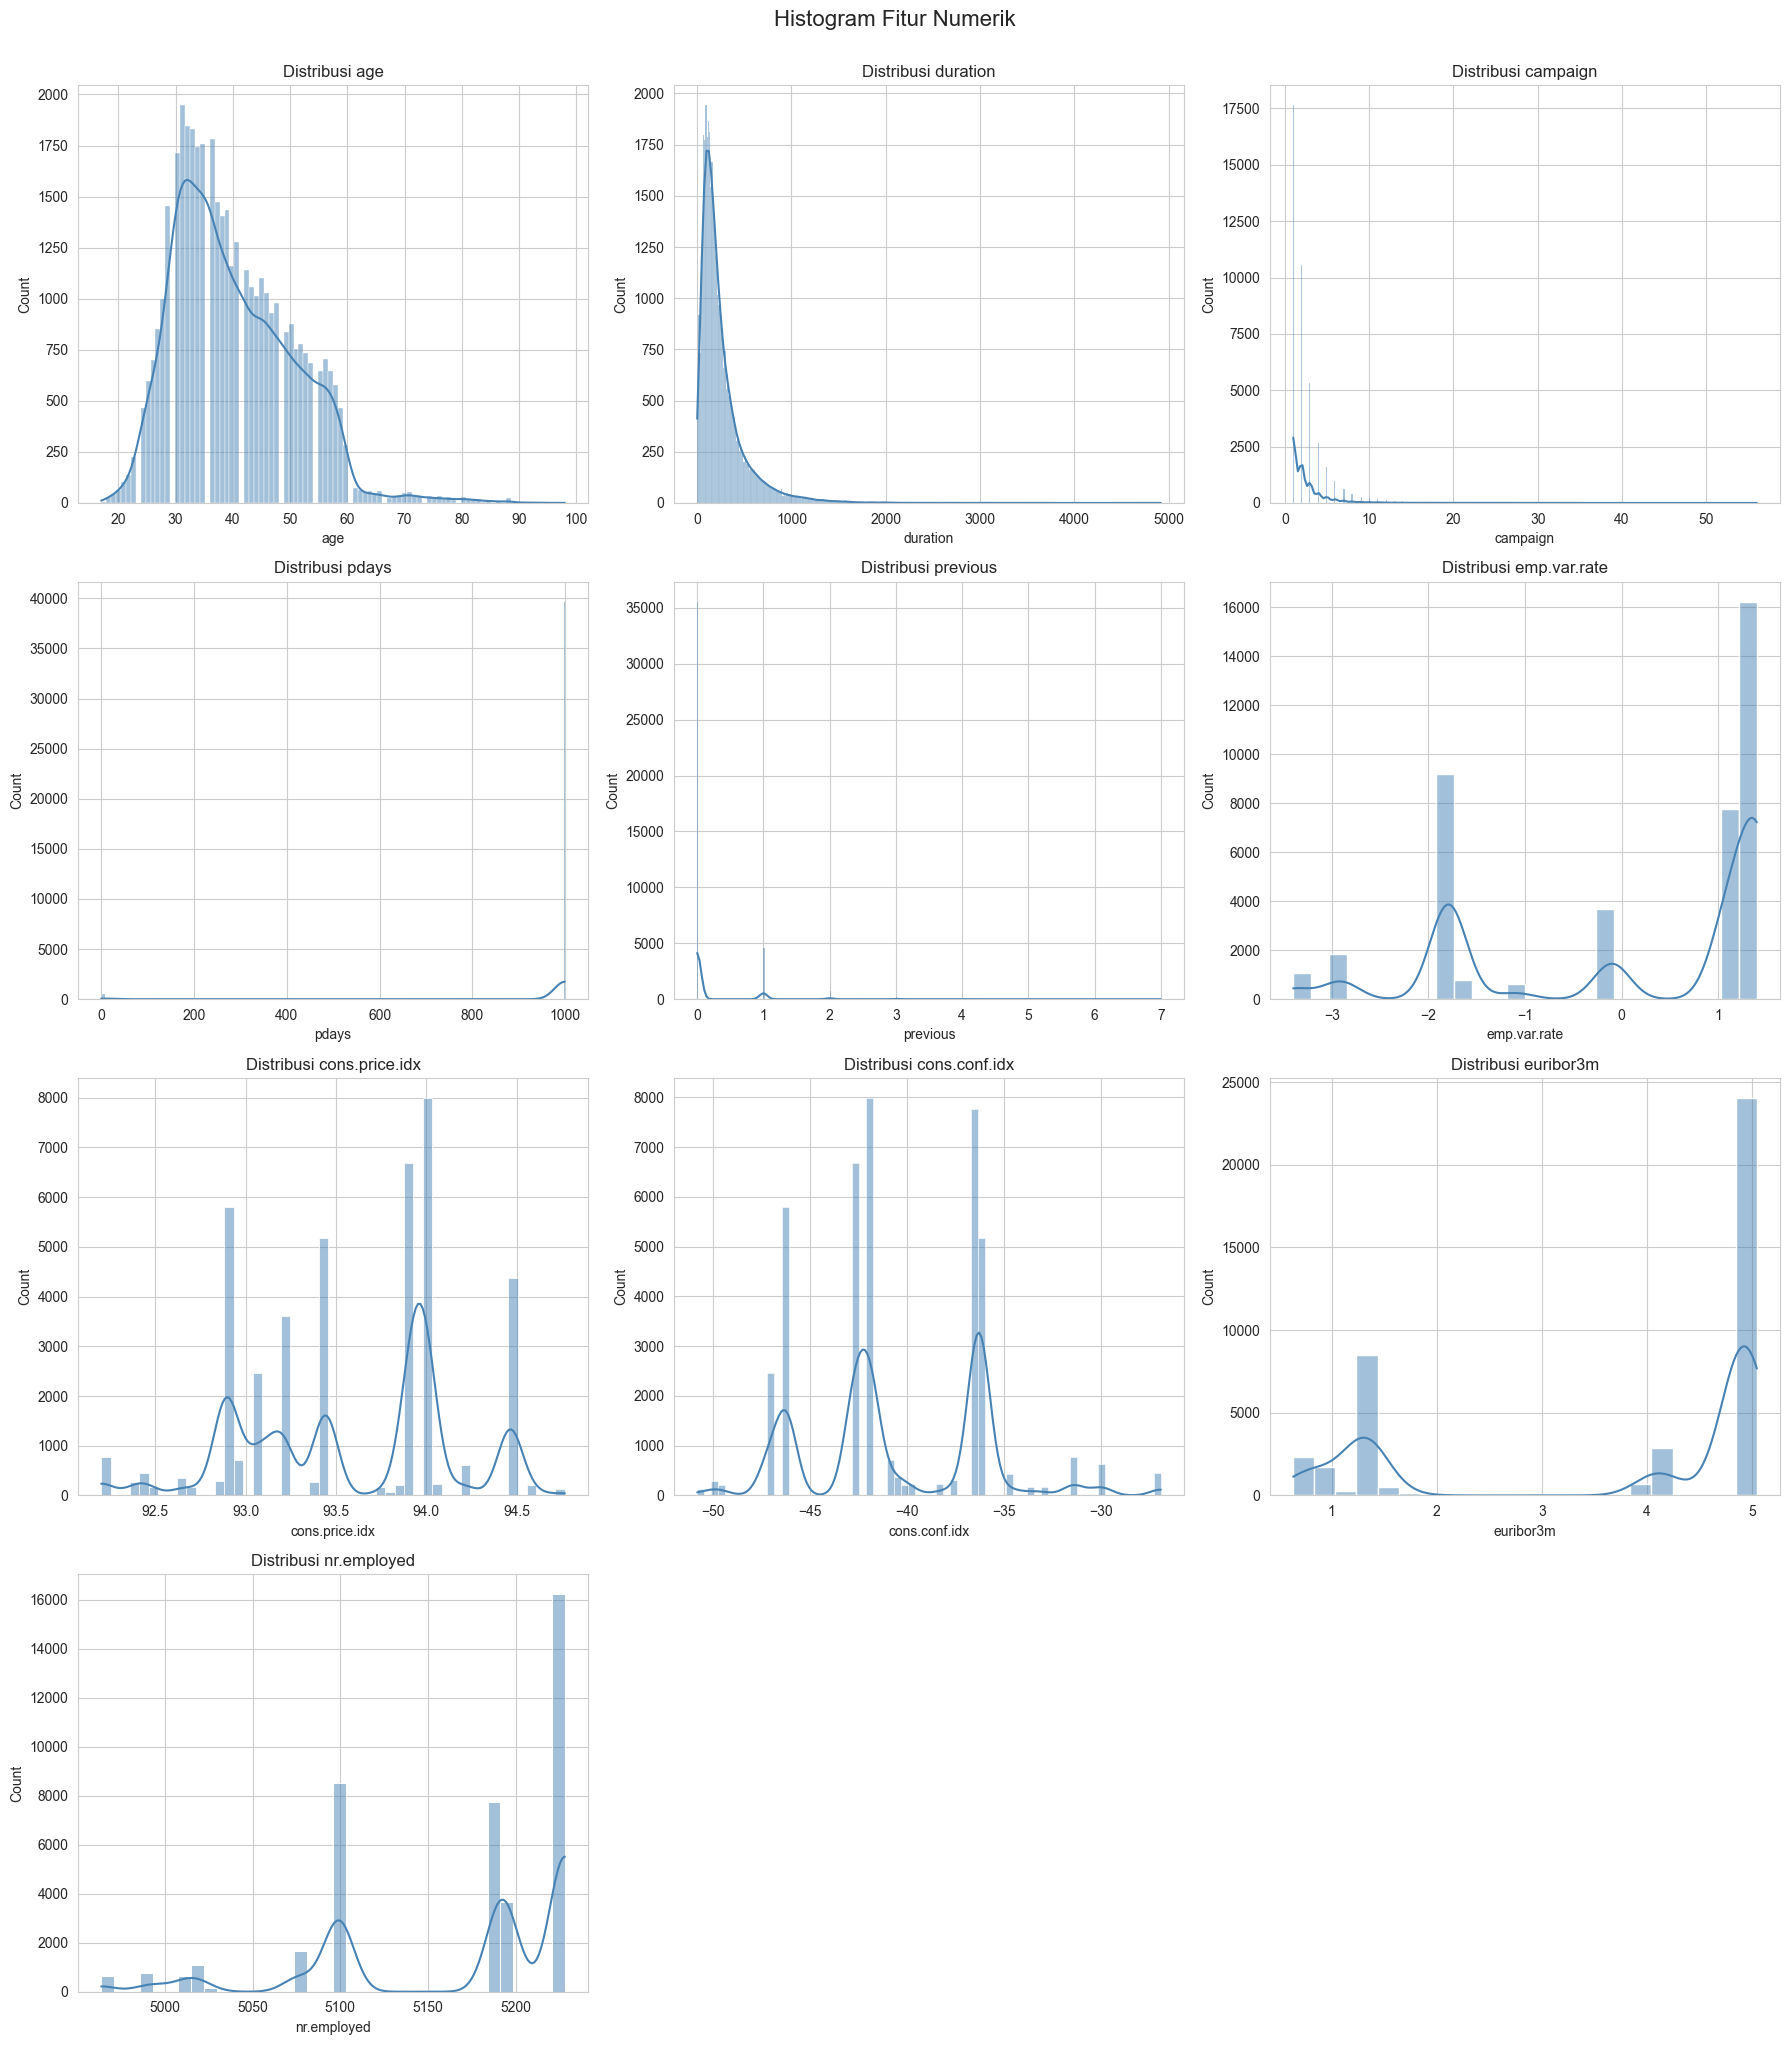

In [7]:
sns.set_style("whitegrid")

n_cols = len(feature_numerical)
n_rows = int(np.ceil(n_cols / 3))

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_numerical):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribusi {col}')

# Matikan axes kosong sisa (kalau jumlah fitur tidak pas kelipatan 3)
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Histogram Fitur Numerik', y=1.02, fontsize=16)
plt.show()

####b. Boxplot untuk deteksi outlier

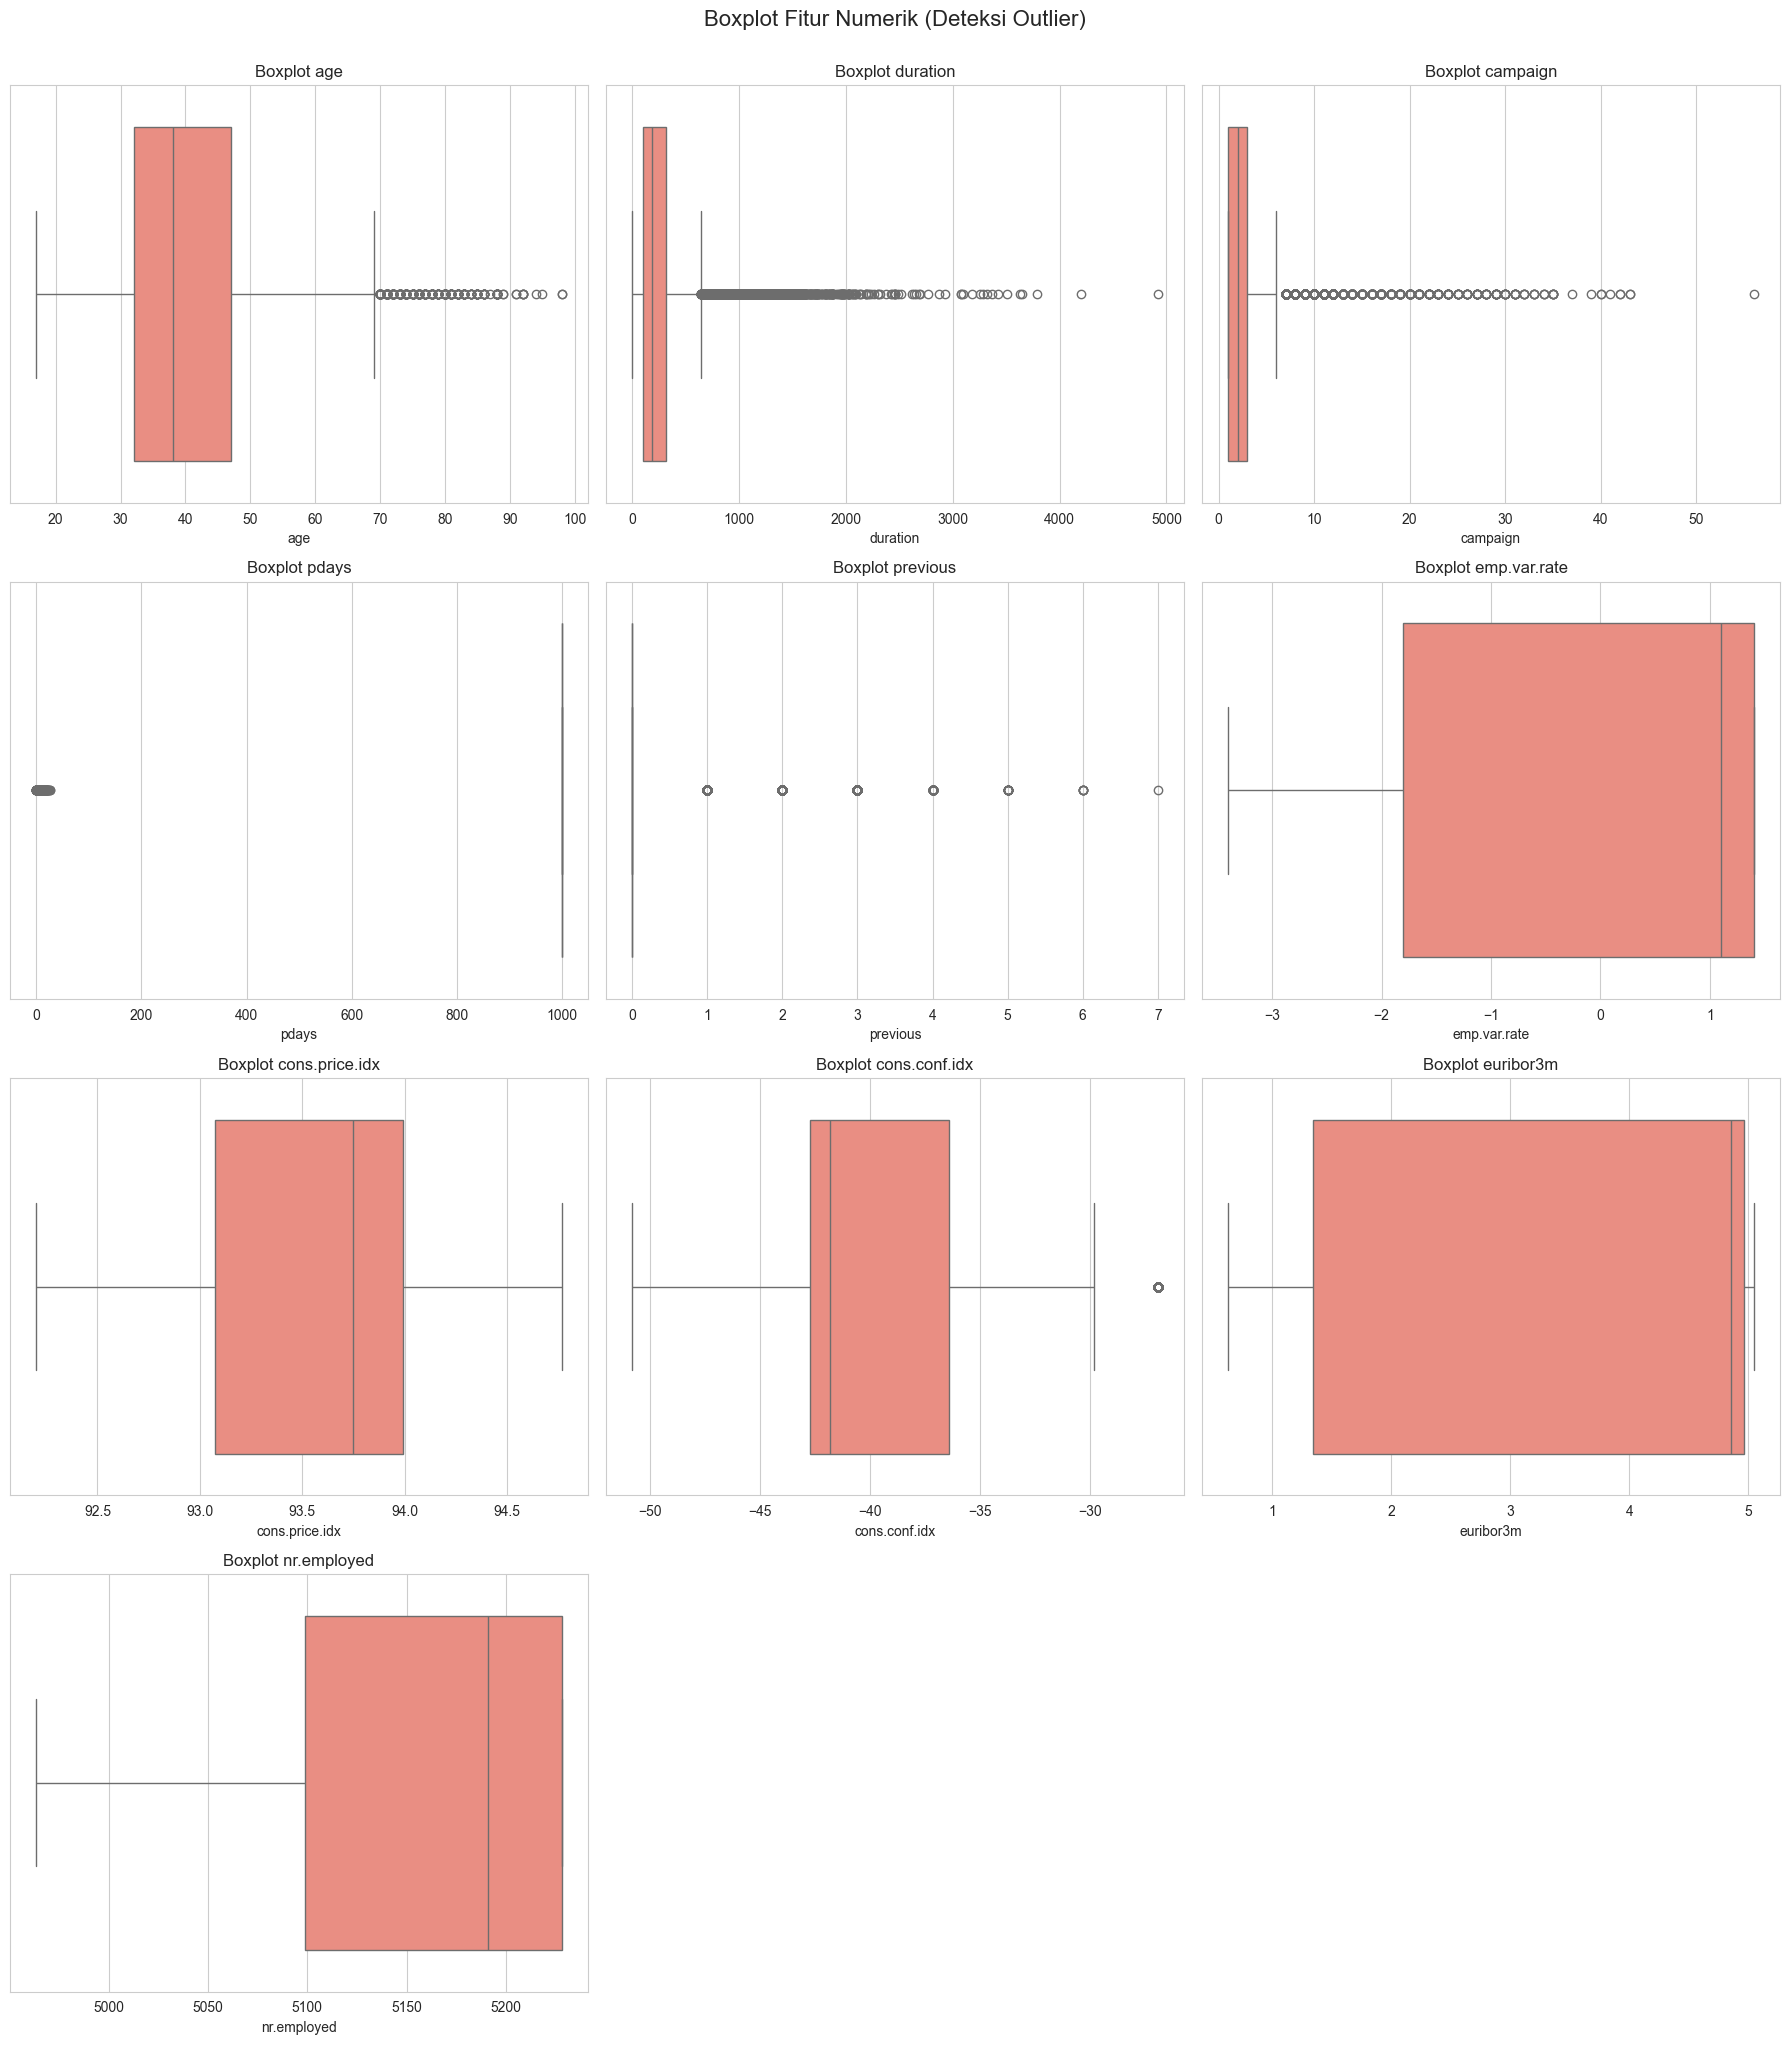

In [8]:
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
axes = axes.flatten()
for i, col in enumerate(feature_numerical):
    sns.boxplot(x=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'Boxplot {col}')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.suptitle('Boxplot Fitur Numerik (Deteksi Outlier)', y=1.02, fontsize=16)
plt.show()


####c. QQ-plot untuk cek normalitas distribusi

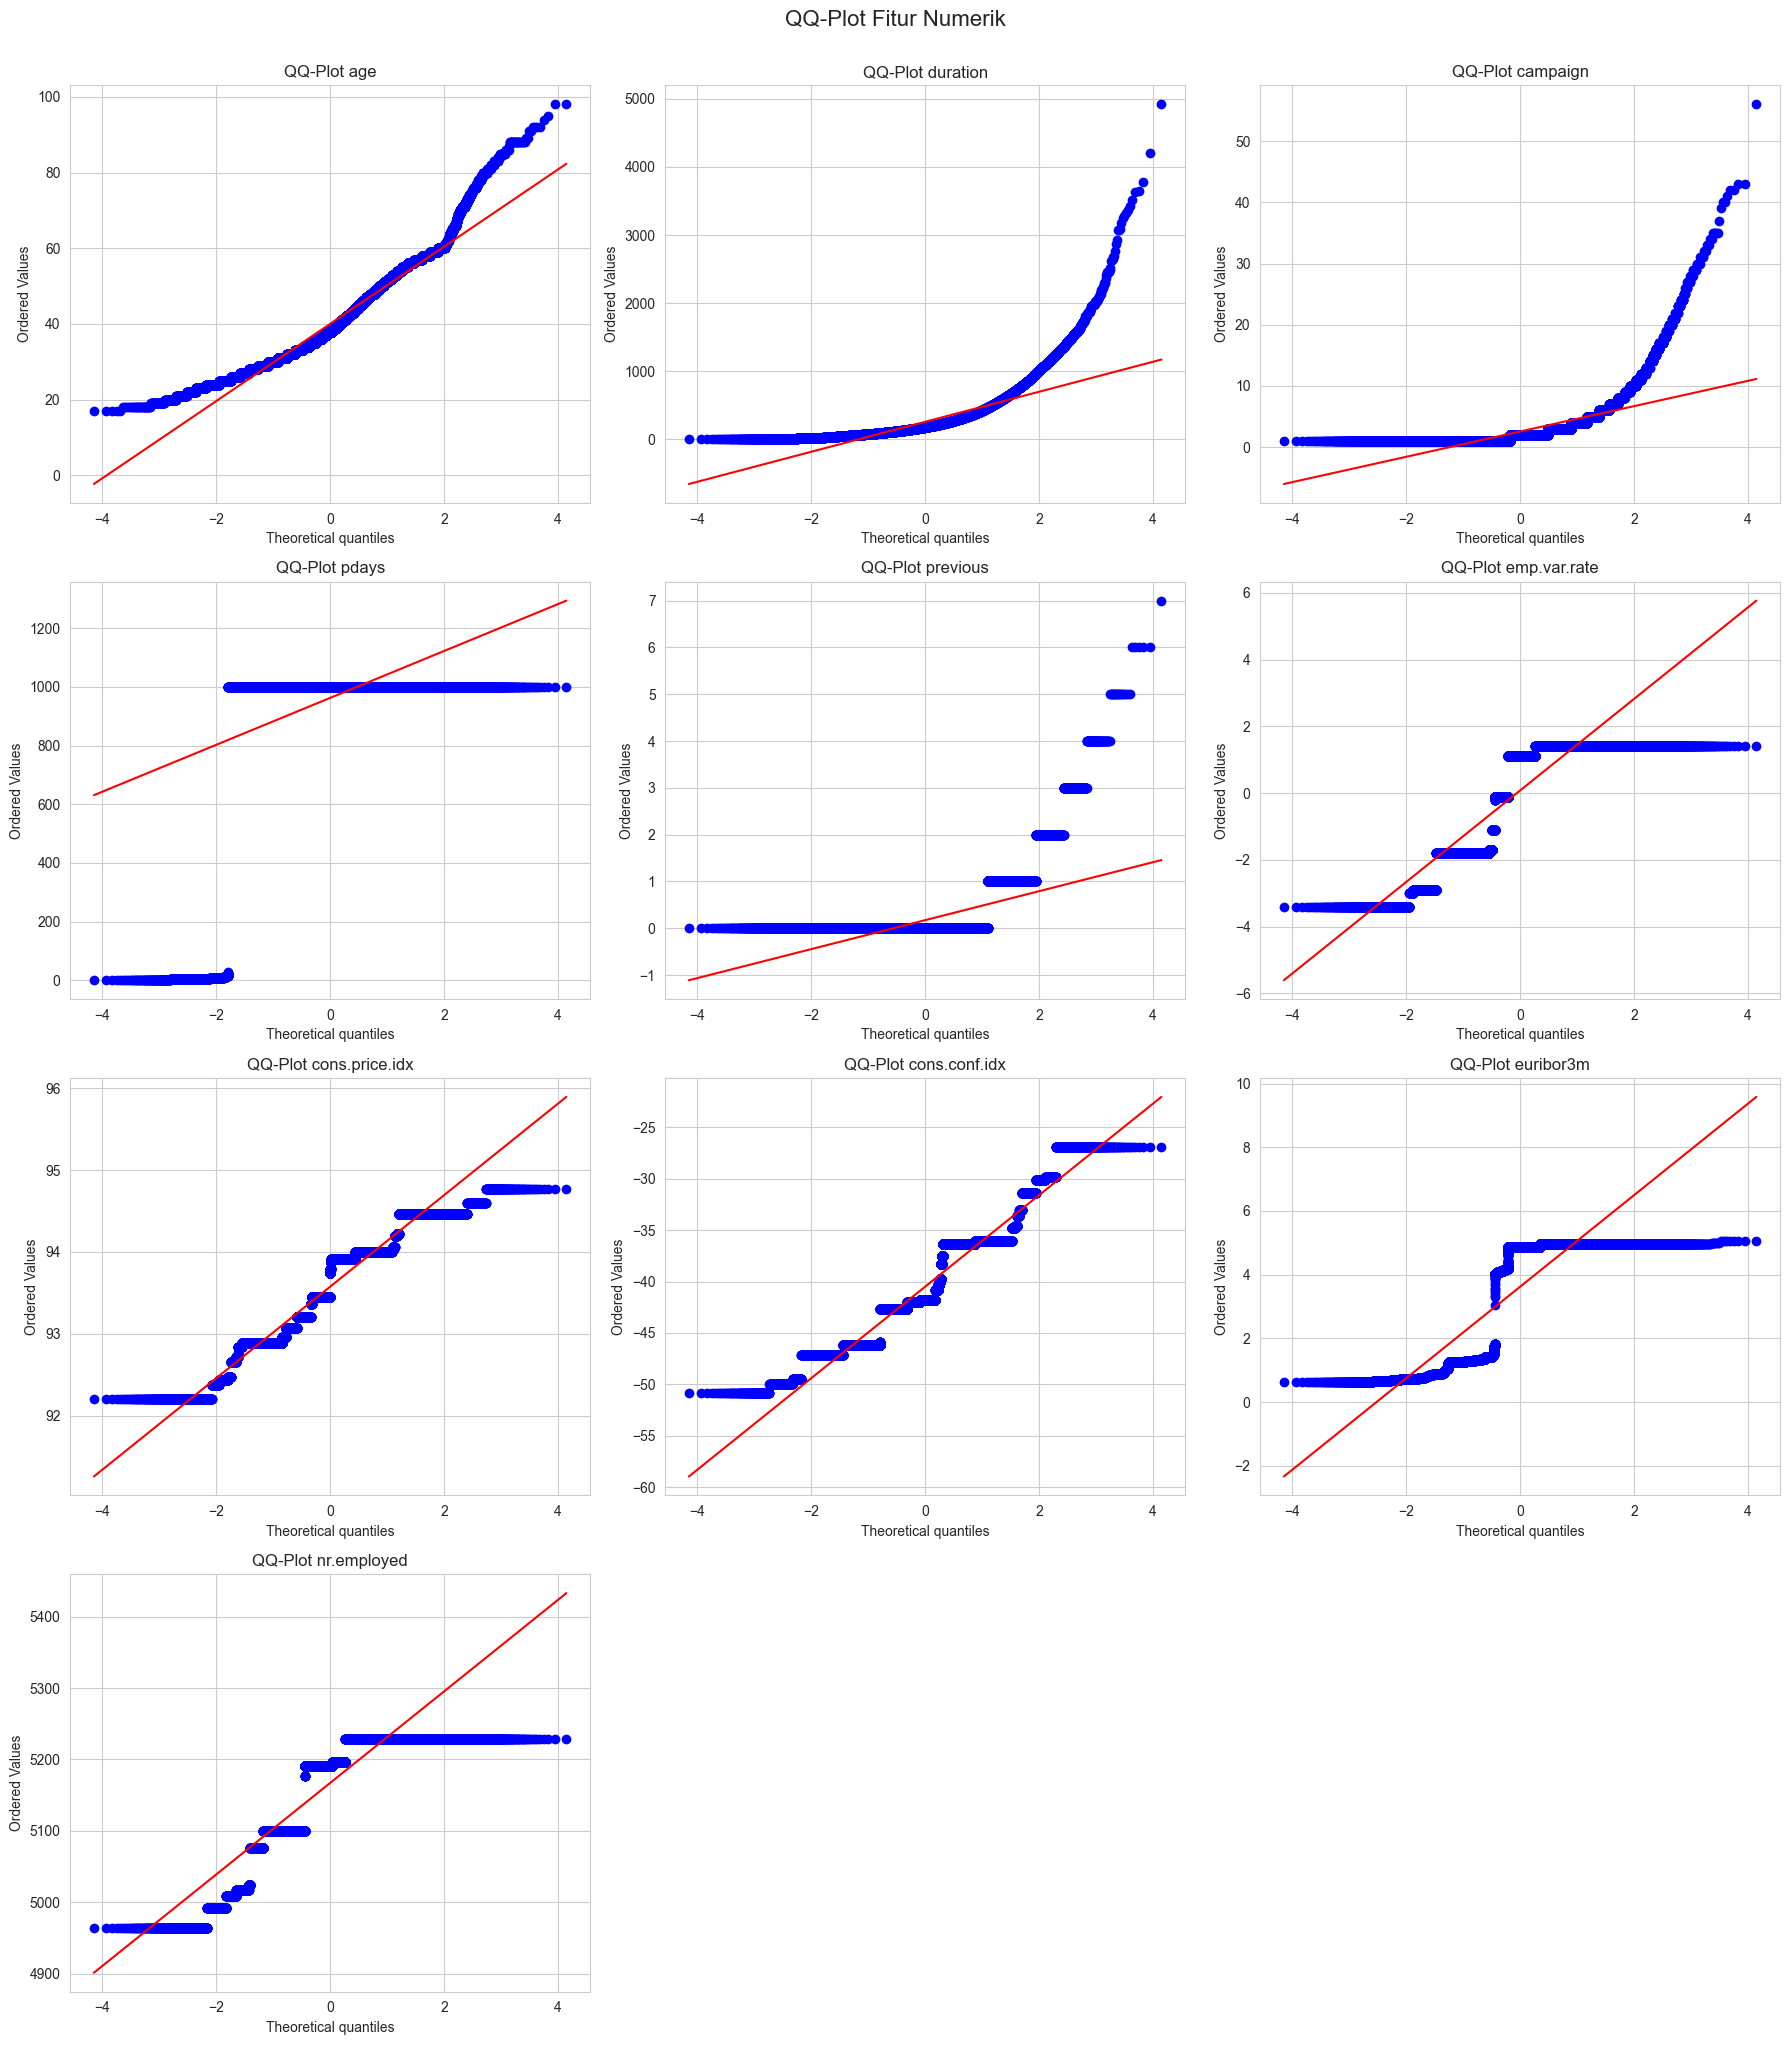

In [9]:
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
axes = axes.flatten()
for i, col in enumerate(feature_numerical):
    stats.probplot(df[col], dist="norm", plot=axes[i])
    axes[i].set_title(f'QQ-Plot {col}')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.suptitle('QQ-Plot Fitur Numerik', y=1.02, fontsize=16)
plt.show()

**Insight**

- duration, campaign, previous sangat right-skewed (mean jauh di atas median, contoh: duration mean=258 vs median=180) → berpotensi banyak outlier di boxplot, dan QQ-plot akan menunjukkan penyimpangan besar dari garis normal di ujung kanan.

- pdays: 999 mendominasi (39.673 dari 41.188 baris = 96,3%). Ini bukan outlier biasa, tapi sentinel value yang artinya "belum pernah dihubungi sebelumnya". Histogram akan terlihat aneh (satu batang raksasa di 999) — perlu ditangani khusus di preprocessing, bukan dianggap outlier numerik biasa.

- age relatif mendekati normal tapi tetap ada ekor kanan (usia lansia).

- emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed adalah indikator makroekonomi → sifatnya lebih diskrit/berulang (bukan kontinu murni), karena nilainya sama untuk banyak nasabah yang dikontak di periode sama.

###2. Data Correlation (Nominal & Ratio Scale)

####a. Korelasi antar fitur numerik (Pearson - ratio/interval scale)

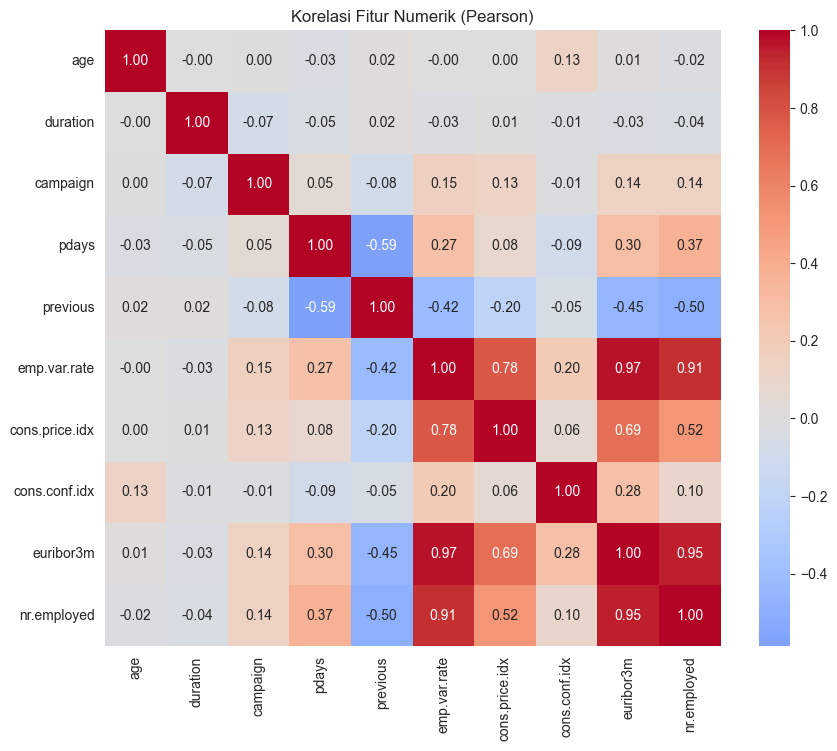

In [10]:
plt.figure(figsize=(10, 8))
corr_numerical = df[feature_numerical].corr(method='pearson')
sns.heatmap(corr_numerical, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Korelasi Fitur Numerik (Pearson)')
plt.show()


####b.Korelasi antar fitur kategorikal (Nominal - Cramér's V)

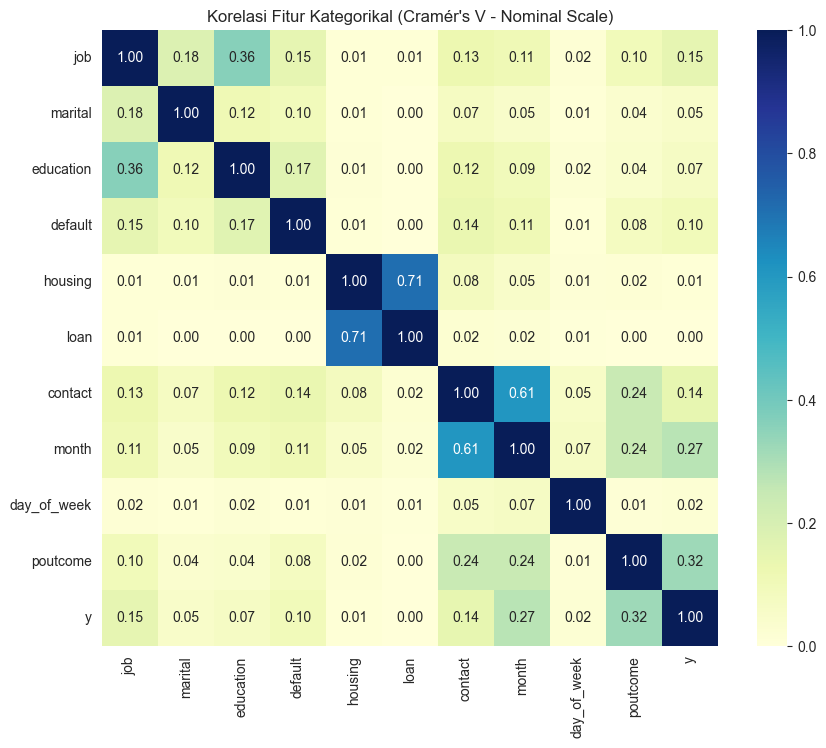

In [11]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_cols = list(feature_categorical)
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

plt.figure(figsize=(10, 8))
sns.heatmap(cramers_matrix.astype(float), annot=True, fmt='.2f', cmap='YlGnBu', square=True)
plt.title("Korelasi Fitur Kategorikal (Cramér's V - Nominal Scale)")
plt.show()

####c. Korelasi fitur numerik terhadap target (y)

In [12]:
df['y_binary'] = df['y'].map({'no': 0, 'yes': 1})
corr_target = df[feature_numerical].corrwith(df['y_binary']).sort_values(ascending=False)
print("Korelasi fitur numerik terhadap target (y):")
print(corr_target)

Korelasi fitur numerik terhadap target (y):
duration          0.405274
previous          0.230181
cons.conf.idx     0.054878
age               0.030399
campaign         -0.066357
cons.price.idx   -0.136211
emp.var.rate     -0.298334
euribor3m        -0.307771
pdays            -0.324914
nr.employed      -0.354678
dtype: float64


***Insight:***

- Fitur makroekonomi (emp.var.rate, euribor3m, nr.employed, cons.price.idx) biasanya berkorelasi sangat tinggi satu sama lain (multikolinearitas) karena semuanya mencerminkan kondisi ekonomi periode yang sama → perlu diwaspadai kalau nanti masuk ke model linear (bisa dipertimbangkan drop salah satu / gunakan PCA).

- pdays dan previous biasanya berkorelasi kuat (logis: kalau previous=0 maka pdays=999).

- poutcome, contact, dan month sering menunjukkan asosiasi (Cramér's V) yang cukup tinggi terhadap target karena berkaitan dengan strategi campaign.

- duration biasanya fitur numerik dengan korelasi paling kuat ke target — tapi ini fitur "bocor" (data leakage), karena durasi telepon baru diketahui setelah panggilan selesai. Untuk model prediktif real-world, fitur ini lazim di-drop.

###3. Data Cardinality (Unique Count Fitur Kategorikal)

In [13]:
cardinality = pd.DataFrame({
    'n_unique': df[feature_categorical].nunique(),
    'unique_values': [df[c].unique().tolist() for c in feature_categorical]
}).sort_values('n_unique', ascending=False)

print(cardinality)

             n_unique                                      unique_values
job                12  [housemaid, services, admin., blue-collar, tec...
month              10  [may, jun, jul, aug, oct, nov, dec, mar, apr, ...
education           8  [basic.4y, high.school, basic.6y, basic.9y, pr...
day_of_week         5                          [mon, tue, wed, thu, fri]
marital             4               [married, single, divorced, unknown]
default             3                                 [no, unknown, yes]
housing             3                                 [no, yes, unknown]
loan                3                                 [no, yes, unknown]
poutcome            3                    [nonexistent, failure, success]
contact             2                              [telephone, cellular]
y                   2                                          [no, yes]


***Insight :***
| Fitur | Jumlah Unique | Keterangan |
|---|---:|---|
| `job` | 12 | Termasuk kategori `unknown` |
| `education` | 8 | Termasuk `unknown`; memiliki tingkatan (`basic.4y` / `basic.6y` / `basic.9y`) → bersifat ordinal dan dapat di-encode berdasarkan urutan |
| `month` | 10 | Tidak terdapat Januari (`jan`) dan Februari (`feb`) → terdapat potensi bias musiman pada data |
| `marital` | 3 | Low cardinality |
| `default` | 3 | Low cardinality |
| `housing` | 3 | Low cardinality |
| `loan` | 3 | Low cardinality |
| `poutcome` | 3 | Low cardinality |
| `contact` | 2 | Binary |
| `y` | 2 | Binary / target variable |
| `day_of_week` | 5 | Hanya mencakup Senin–Jumat |

→ Semua fitur kategorikal low-to-medium cardinality, aman untuk One-Hot Encoding (kecuali education yang lebih cocok Ordinal Encoding).

###4. Missing Value, Outlier, Anomali, Duplikat

##### a. Missing value eksplisit (NaN)

In [14]:
print("Missing value (NaN) per kolom:")
print(df.isnull().sum())

Missing value (NaN) per kolom:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
y_binary          0
dtype: int64


####b. 'unknown' sebagai missing value tersembunyi

In [15]:
print("\nJumlah 'unknown' per kolom kategorikal:")
for col in feature_categorical:
    n_unknown = (df[col] == 'unknown').sum()
    if n_unknown > 0:
        print(f"{col}: {n_unknown} ({n_unknown/len(df)*100:.2f}%)")


Jumlah 'unknown' per kolom kategorikal:
job: 330 (0.80%)
marital: 80 (0.19%)
education: 1731 (4.20%)
default: 8597 (20.87%)
housing: 990 (2.40%)
loan: 990 (2.40%)


####c. Duplikat

In [16]:
print(f"\nJumlah baris duplikat penuh: {df.duplicated().sum()}")
display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))


Jumlah baris duplikat penuh: 12


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,y_binary
28476,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no,0
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no,0
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no,0
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no,0
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no,0
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no,0
32505,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no,0
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no,0
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no,0
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no,0


#### d. Outlier via IQR method

In [17]:
print("\nJumlah outlier (IQR method) per kolom numerik:")
for col in feature_numerical:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outlier} outlier ({n_outlier/len(df)*100:.2f}%)")


Jumlah outlier (IQR method) per kolom numerik:
age: 469 outlier (1.14%)
duration: 2963 outlier (7.19%)
campaign: 2406 outlier (5.84%)
pdays: 1515 outlier (3.68%)
previous: 5625 outlier (13.66%)
emp.var.rate: 0 outlier (0.00%)
cons.price.idx: 0 outlier (0.00%)
cons.conf.idx: 447 outlier (1.09%)
euribor3m: 0 outlier (0.00%)
nr.employed: 0 outlier (0.00%)


####e. Anomali spesifik pdays

In [18]:
print(f"\npdays = 999 (belum pernah dikontak): {(df['pdays']==999).sum()} baris ({(df['pdays']==999).mean()*100:.1f}%)")


pdays = 999 (belum pernah dikontak): 39673 baris (96.3%)


***Insight : ***

a. Tidak ada NaN eksplisit — tapi ada missing tersembunyi berupa "unknown" di 6 kolom kategorikal:

- default: 20.87% unknown ⚠️ (cukup besar, hati-hati)
- education: 4.20%
- housing & loan: 2.40% masing-masing
- job: 0.80%
- marital: 0.19%


b. Duplikat: 12 baris persis sama di semua kolom → perlu dihapus.

c. Outlier (metode IQR) diperkirakan cukup banyak di duration, campaign, previous, age karena sifat distribusinya yang skewed — namun untuk kasus marketing campaign, outlier ini kemungkinan bukan error, melainkan variasi bisnis yang valid (misal nasabah lama ditelepon = durasi telepon lama), jadi tidak otomatis dihapus, cukup di-cap/transform.

d. pdays=999 bukan outlier, tapi placeholder untuk "belum pernah dihubungi" (96,3% data) → harus ditangani sebagai kategori/flag terpisah, bukan angka kontinu biasa.

e. Target y imbalanced: 88,7% "no" vs 11,3% "yes" → penting dicatat untuk tahap modeling nanti (perlu teknik resampling/class-weight).

## D. PREPROCESSING

### 1. Fill Missing Value

In [37]:
df_clean = df.copy()

# 'unknown' diperlakukan sebagai missing value, diisi dengan modus per kolom
# for col in ['job', 'marital', 'education', 'default', 'housing', 'loan']:
#     mode_val = df_clean.loc[df_clean[col] != 'unknown', col].mode()[0]
#     n_before = (df_clean[col] == 'unknown').sum()
#     df_clean[col] = df_clean[col].replace('unknown', mode_val)
#     print(f"{col}: {n_before} 'unknown' diisi dengan modus '{mode_val}'")

***Insight:***

Karena tidak ada NaN eksplisit, strategi imputasi difokuskan pada "unknown". Digunakan modus (nilai paling sering muncul) karena semua fitur ini nominal/ordinal. Khusus default (20,9% unknown), alternatif lain yang lebih aman adalah mempertahankan "unknown" sebagai kategori tersendiri (bukan diimput), karena proporsinya besar dan kemungkinan punya makna bisnis (nasabah menyembunyikan status kredit macet). Silakan sesuaikan sesuai tujuan analisis — saya beri opsi alternatif di bawah:

###2. Casting Data Type

In [38]:
# Kolom ordinal -> category dengan urutan eksplisit
education_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                    'high.school', 'professional.course', 'university.degree']
df_clean['education'] = pd.Categorical(df_clean['education'], categories=education_order, ordered=True)

# Kolom nominal -> category
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan',
                 'contact', 'month', 'day_of_week', 'poutcome', 'y']
for col in nominal_cols:
    df_clean[col] = df_clean[col].astype('category')

# Kolom numerik -> pastikan tipe sesuai
int_cols = ['age', 'duration', 'campaign', 'pdays', 'previous']
for col in int_cols:
    df_clean[col] = df_clean[col].astype('int64')

float_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
for col in float_cols:
    df_clean[col] = df_clean[col].astype('float64')

print(df_clean.dtypes)

age                  int64
job               category
marital           category
education         category
default           category
housing           category
loan              category
contact           category
month             category
day_of_week       category
duration             int64
campaign             int64
pdays                int64
previous             int64
poutcome          category
emp.var.rate       float64
cons.price.idx     float64
cons.conf.idx      float64
euribor3m          float64
nr.employed        float64
y                 category
y_binary             int64
dtype: object


***Insight:***

education di-casting sebagai ordered category karena punya tingkatan jelas (SD → S1), sehingga nanti bisa di-encode sebagai angka urut (Ordinal Encoding) alih-alih One-Hot — ini menjaga informasi urutan yang bermakna.

###3. Inconsistent Variable

In [39]:
# Cek konsistensi nilai antar kolom terkait
print("Cek konsistensi pdays vs previous vs poutcome:")
print(pd.crosstab(df_clean['pdays']==999, df_clean['poutcome']))

# Standarisasi nama kolom (titik -> underscore, biar konsisten & mudah diakses)
df_clean.columns = df_clean.columns.str.replace('.', '_', regex=False)

# Cek konsistensi kapitalisasi/spasi pada seluruh kolom object/category
for col in df_clean.select_dtypes(include='category').columns:
    print(col, ':', sorted(df_clean[col].unique().astype(str)))

Cek konsistensi pdays vs previous vs poutcome:
poutcome  failure  nonexistent  success
pdays                                  
False         142            0     1373
True         4110        35563        0
job : [np.str_('admin.'), np.str_('blue-collar'), np.str_('entrepreneur'), np.str_('housemaid'), np.str_('management'), np.str_('retired'), np.str_('self-employed'), np.str_('services'), np.str_('student'), np.str_('technician'), np.str_('unemployed'), np.str_('unknown')]
marital : [np.str_('divorced'), np.str_('married'), np.str_('single'), np.str_('unknown')]
education : ['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', np.str_('nan'), 'professional.course', 'university.degree']
default : [np.str_('no'), np.str_('unknown'), np.str_('yes')]
housing : [np.str_('no'), np.str_('unknown'), np.str_('yes')]
loan : [np.str_('no'), np.str_('unknown'), np.str_('yes')]
contact : [np.str_('cellular'), np.str_('telephone')]
month : [np.str_('apr'), np.str_('aug'), np.str_('dec'

***Insight:***

 Nama kolom seperti emp.var.rate, cons.price.idx mengandung titik (.) yang berisiko error saat diakses via df.emp.var.rate (dianggap atribut bertingkat) → diseragamkan jadi underscore (emp_var_rate). Dari cek silang, pdays=999 selalu konsisten dengan poutcome='nonexistent' — tidak ditemukan baris yang aneh (misal pdays≠999 tapi poutcome='nonexistent'), artinya data cukup konsisten secara logika bisnis.

###4. Remove Duplicate

In [40]:
print(f"Jumlah baris sebelum hapus duplikat: {len(df_clean)}")
df_clean = df_clean.drop_duplicates(keep='first').reset_index(drop=True)
print(f"Jumlah baris setelah hapus duplikat: {len(df_clean)}")

Jumlah baris sebelum hapus duplikat: 41188
Jumlah baris setelah hapus duplikat: 41176


***Insight:***

12 baris duplikat penuh dihapus (0,03% dari total data) — dampaknya minimal terhadap distribusi data, tapi tetap penting dihapus agar tidak menggandakan bobot observasi tertentu saat training model.

###5. Feature Engineering

In [41]:
#a. Flag apakah nasabah pernah dikontak sebelumnya (dari pdays)
df_clean['was_contacted_before'] = np.where(df_clean['pdays'] == 999, 0, 1)

#b. Ganti nilai sentinel 999 pada pdays jadi -1 supaya tidak merusak skala numerik
#     (karena 999 bukan "962 hari" sungguhan, hanya penanda "tidak pernah")
# kalo diganti 0 bisa nambah bias, karena 0 = "baru saja dikontak" (bukan "belum pernah")
df_clean['pdays_clean'] = np.where(df_clean['pdays'] == 999, -1, df_clean['pdays'])

#c. Age binning -> kelompok usia (kategori lebih interpretable utk campaign)
df_clean['age_group'] = pd.cut(df_clean['age'],
                                 bins=[0, 25, 35, 45, 55, 65, 100],
                                 labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+'])

#d. Flag pernah punya campaign sebelumnya (previous > 0)
df_clean['has_previous_contact'] = (df_clean['previous'] > 0).astype(int)

#e. Kelompokkan bulan ke kuartal (opsional, mengurangi cardinality musiman)
month_to_quarter = {'jan':'Q1','feb':'Q1','mar':'Q1','apr':'Q2','may':'Q2','jun':'Q2',
                     'jul':'Q3','aug':'Q3','sep':'Q3','oct':'Q4','nov':'Q4','dec':'Q4'}
df_clean['quarter'] = df_clean['month'].map(month_to_quarter)

#f. Encode target jadi biner
df_clean['y'] = df_clean['y'].map({'no': 0, 'yes': 1}).astype('int64')

df_clean.head()
# df_clean.save

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,y_binary,was_contacted_before,pdays_clean,age_group,has_previous_contact,quarter
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0,-1,55-64,0,Q2
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0,-1,55-64,0,Q2
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0,-1,35-44,0,Q2
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0,-1,35-44,0,Q2
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0,-1,55-64,0,Q2


***Insight:***

 Fitur baru dibuat berdasarkan temuan EDA:
- was_contacted_before mengubah info sentinel 999 menjadi flag biner yang lebih bermakna secara statistik.
- pdays_clean menghindari 999 merusak skala/korelasi saat dipakai model numerik langsung.
- age_group & quarter menyederhanakan fitur kontinu/kardinalitas tinggi jadi kategori bisnis yang lebih interpretable untuk analisis campaign.
- Target y di-encode biner (0/1) agar siap dipakai untuk modeling klasifikasi.

## E. Methodology (Data Analytics)

Bagian ini akan menjawab problem statement secara deskriptif: Nasabah dengan karakteristik apa, pada waktu dan kanal apa, serta pada panggila keberapa yang paling layak diprioritaskan bank agar kampanye telemarketing menjadi efisien?

Analisis pada bagian pada bagian ini disusun dengan mnejawab 5W-1H supaya setiap temuan langsung terhubung ke keputusan operasional tim telemarketing

Dua paradigma analisis akan dipakai dalam bagian tersebut:
1. Analisis deskriptif: menceritakan pola melalui statistik ringkas dan visualisasi.
2. Analisis inferensial: menguji apakah pola tersebut signifikan secara statistik (dengan chi-square, Cramer's V, Mann-Whitney U, two-proportion z-test), sehingga rekomendasi tidak dibangun di atas perbedaan yang sebenarnya kebetulan sampel.

### a. Seberapa Besar Masalahnya?

Sebelum mencari segmen terbaik, besarnya masalah harus dikulik terlebih dahulu sebagai pembanding seluruh rekomendasi di bagian akhir. Semua analisis di bagian tersebut akan menggunakan `df_clean` dengan empat acuan, yaitu jumlah nasabah dikontak, jumlah deposan, baseline conversion rate, dan total panggilan. Keempat acuan ini akan dipakai secara berulang sebagai pembanding pada semua grafik dan uji statistik di sub-bab selanjutnya.

In [ ]:
# Initialization
n_nasabah = len(df_clean)
n_deposan = df_clean['y'].sum()
baseline_rate = df_clean['y'].mean() * 100 # dalam persen
total_call = df_clean['campaign'].sum()

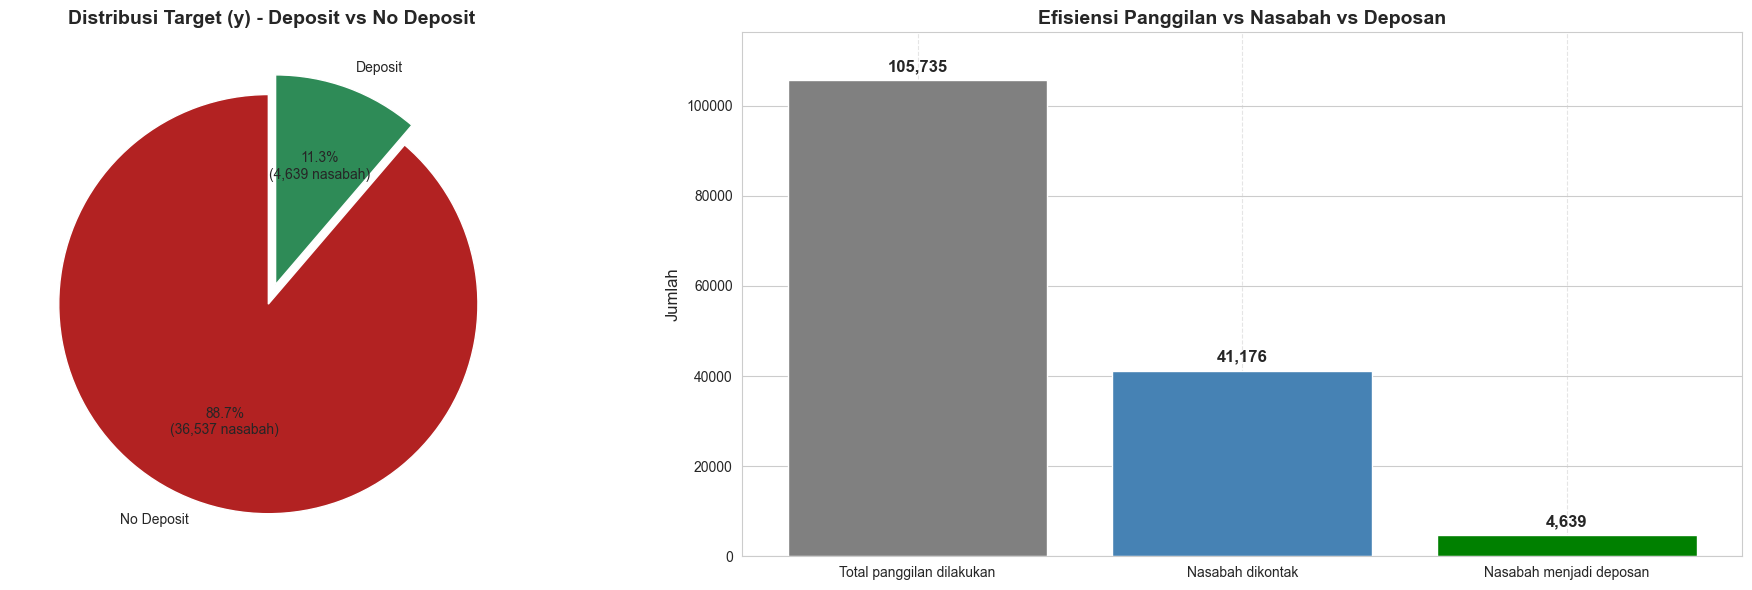

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].pie(df_clean['y'].value_counts(), 
            labels=['No Deposit', 'Deposit'], 
            autopct=lambda p: f'{p:.1f}%\n({p*n_nasabah/100:,.0f} nasabah)', 
            startangle=90, 
            colors=['firebrick', 'seagreen'],
            explode=(0.05, 0.05))
axes[0].set_title("Distribusi Target (y) - Deposit vs No Deposit", fontsize=14, weight="bold")

efisiensi_call = pd.Series({
    "Total panggilan dilakukan": total_call,
    "Nasabah dikontak": n_nasabah,
    "Nasabah menjadi deposan": n_deposan,
})
bar = axes[1].bar(efisiensi_call.index, efisiensi_call.values, color=['grey', 'steelblue', 'green'])
for b, v in zip(bar, efisiensi_call.values):
    axes[1].text(b.get_x() + b.get_width()/2, v + 2000, f"{v:,}", ha='center', fontsize=12, weight="bold")
axes[1].set_title("Efisiensi Panggilan vs Nasabah vs Deposan", fontsize=14, weight="bold")
axes[1].set_ylabel("Jumlah", fontsize=12)
axes[1].set_ylim(0, total_call*1.1)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

In [44]:
# Detail
print(f"Jumlah nasabah                              : {n_nasabah:,}")
print(f"Jumlah deposan                              : {n_deposan:,}")
print(f"Baseline conversion rate                    : {baseline_rate:.2f}%")
print(f"Total panggilan dilakukan                   : {total_call:,} kali")
print(f"Rata-rata panggilan per nasabah             : {total_call/n_nasabah:.2f} panggilan/nasabah")
print(f"Pangilan per deposan                        : {total_call/n_deposan:.2f} kali/deposan")
print(f"Panggilan yang tidak menghasilkan deposan   : {total_call - n_deposan:,} ({(total_call - n_deposan)/total_call*100:.2f}%)")

Jumlah nasabah                              : 41,176
Jumlah deposan                              : 4,639
Baseline conversion rate                    : 11.27%
Total panggilan dilakukan                   : 105,735 kali
Rata-rata panggilan per nasabah             : 2.57 panggilan/nasabah
Pangilan per deposan                        : 22.79 kali/deposan
Panggilan yang tidak menghasilkan deposan   : 101,096 (95.61%)


**INSIGHT**

Dari total 41.176 nasabah yang dihubungi, hanya 4.639 nasabah (11,27%) yang akhirnya menempatkan deposito. Karena satu nasabah rata-rata ditelpon sebanyak 2-3 kali (dihitung secara mutlak), total panggilan sebenarnya adalah 105.735 panggilan. Artinya, bank perlu sekitar 23 panggilan untuk mendapatkan 1 deposan, dan 95,6% panggilan tidak menghasilkan deposito sama sekali.

Angka 22,8 panggilan/deposan menjadi tumpu yang akan dipakai untuk menilai seluruh rekomendasi hasil analisis dan bagian kesimpulan. Setiap strategi baru hanya layak diadopsi jika mampu menurunkan rasi ini secara berarti.

### b. Fitur mana yang benar-benar berpengaruh?

Sebelum mengulik ke setiap variable, seluruh fitur kategorikal diuji sekaligus terhadap target dengan menggunakan chi-square test of independence signifikansi dan Cramer's V sebagai kekuatan asosiasi. 

Chi-square test of independence digunakan karena fitur dan target sama-sama dalam bentuk kategorikal, bukan numerikal, sehingga test ini akan menjadi alat utama untuk melihat hubungan antar fitur dan target. Berikut adalah hipotesis ujinya:
- H0: fitur dan keputusan deposito tidak ada hubungan
- H1: fitur dan keputusan deposito ada hubungan
H0 akan ditolak jika p-value < 0.05.


In [51]:
feature_categorical = ['poutcome', 'month', 'job', 'contact', 'default', 'education', 'marital', 'day_of_week', 'housing', 'loan']

results = []
for col in feature_categorical:
    tabel = pd.crosstab(df_clean[col], df_clean['y'])
    chi2, p, dof, expected = chi2_contingency(tabel)  # expected = jumlah bila H0 benar
    results.append([col, tabel.shape[0], round(chi2, 2), p, dof, round(expected.min(), 1)])

test = pd.DataFrame(results, columns=['feature', 'n_categories', 'chi2_stat', 'p_value', 'dof', 'min_expected'])
test['kesimpulan'] = np.where((test['p_value'] < 0.05) , 'Tolak H0 (Ada hubungan)', 'Gagal Tolak H0 (Tidak ada hubungan)')
test = test.sort_values('p_value').reset_index(drop=True)
display(test)
print(f"Fitur yang terbukti berhubungan pada alpha 5%: {(test['p_value'] < 0.05).sum()} dari {len(test)} fitur kategorikal")

# Cek asumsi chi square: expected frequency > 5 untuk semua sel
print("\nCek asumsi chi square: expected frequency > 5 untuk semua sel")
melanggar = test.loc[test['min_expected'] < 5, 'feature'].tolist()
if not melanggar:
    print('Terpenuhi pada seluruh fitur.')
for kolom in melanggar:
    tabel   = pd.crosstab(df_clean[kolom], df_clean['y'])
    harapan = pd.DataFrame(stats.chi2_contingency(tabel)[3],
                           index=tabel.index, columns=tabel.columns)
    mini    = harapan.index[harapan.min(axis=1) < 5].tolist()      # kategori penyebabnya
    n_mini  = [int((df_clean[kolom] == m).sum()) for m in mini]
    p_awal  = test.loc[test['feature'] == kolom, 'p_value'].iloc[0]
    # uji ulang tanpa kategori bervolume sangat kecil tersebut
    ulang = df_clean[~df_clean[kolom].isin(mini)]
    chi2b, p_baru, _, harapan_baru = stats.chi2_contingency(
        pd.crosstab(ulang[kolom].astype(str), ulang['y']))
    print(f"TIDAK terpenuhi pada `{kolom}` karena penyebabnya kategori {mini} "
          f"yang hanya berisi {n_mini} baris dari {len(df_clean):,}.")
    print(f"   Diuji ulang tanpa kategori itu: p = {p_baru:.3e} (semula {p_awal:.3e}), "
          f"frekuensi harapan terkecil kini {harapan_baru.min():.1f}"
          f" -> kesimpulan tidak berubah.")

,feature,n_categories,chi2_stat,p_value,dof,min_expected,kesimpulan
0,poutcome,3,4230.14,0.000000e+00,2,154.7,Tolak H0 (Ada hubungan)
1,month,10,3103.03,0.000000e+00,9,20.5,Tolak H0 (Ada hubungan)
2,job,12,961.74,3.268412e-199,11,37.2,Tolak H0 (Ada hubungan)
3,contact,2,862.08,1.718741e-189,1,1694.6,Tolak H0 (Ada hubungan)
4,default,3,406.56,5.217541e-89,2,0.3,Tolak H0 (Ada hubungan)
5,education,7,175.80,2.646943e-35,6,2.0,Tolak H0 (Ada hubungan)
6,marital,4,122.96,1.778423e-26,3,9.0,Tolak H0 (Ada hubungan)
7,day_of_week,5,26.05,3.085755e-05,4,881.7,Tolak H0 (Ada hubungan)
8,housing,3,5.74,5.663793e-02,2,111.5,Gagal Tolak H0 (Tidak ada hubungan)
9,loan,3,1.10,5.771532e-01,2,111.5,Gagal Tolak H0 (Tidak ada hubungan)


Fitur yang terbukti berhubungan pada alpha 5%: 8 dari 10 fitur kategorikal

Cek asumsi chi square: expected frequency > 5 untuk semua sel
TIDAK terpenuhi pada `default` karena penyebabnya kategori ['yes'] yang hanya berisi [3] baris dari 41,176.
   Diuji ulang tanpa kategori itu: p = 3.719e-90 (semula 5.218e-89), frekuensi harapan terkecil kini 968.5 -> kesimpulan tidak berubah.
TIDAK terpenuhi pada `education` karena penyebabnya kategori ['illiterate'] yang hanya berisi [18] baris dari 41,176.
   Diuji ulang tanpa kategori itu: p = 1.756e-38 (semula 2.647e-35), frekuensi harapan terkecil kini 194.8 -> kesimpulan tidak berubah.


Hasilnya, 8 dari 10 fitur menolak H0 yang artinya terbukti mayoritas fitur ada hunungan dengan keputusan deposito. Hanya *housing* dan *loan* yang gagal.

Chi-square menyaratkan frekuensi expectation minimal 5 di setiap sel contingency tablenya. Syarat ini terpenuhi pada 8 fitur, tetapi dilanggar pada *default* dan *education*. Penyebabnya adalah kategori yang bervolume sangat kecil: `default = 'yes'` hanya berisi 3 baris dan `education = 'illiterate'` 18 barus dari 41.176 baris. keduanya diuji ulang tanpa kategori tersebut tetap menghasilkan hasil yang sama (*p* = 3,7 × 10⁻⁹⁰ dan *p* = 1,8 × 10⁻³⁸). Temuan ini penting untuk tahap modeling karena `default = 'yes'` terlalu kecil untuk berdiri sendiri dan sebaiknya digabung ke unknown agar tidak menghasilkan kolom one-hot yang nyaris konstan.

Daftar di atas belum bisa dipakai meilih fitur. Kolom *kesimpulan* memberi label yang persis sama: "Tolak H0 -> ada hubungan" kepada *poutcome* dan *day_on_week*, padahal nilai chi-square keduanya 4.230,1 berbanding 26,1: terpaut 162 kali lipat. Selama yang dibaca hanya p-value atau kolom kesimpulan, kedua fitur itu tampak sangat penting. 

Kenapa tidak memringkatkan mememakai nilai chi-square saja? Karena chi-square ikut membesar menginkuti dua hal yang tidak ada hubungannya dengan kuat-lemahnya asosiasi: jumlah sampel dan ukuran tabel kontingensi. Bandingkan `month` (10 kategori, dof 8, chi2 = 3103.0) dengan `contact` (2 kategori, dof 1, chi2 = 862.1), angka mentahnya tidak setara karena tabelnya beda ukuran, bukan karena hubunganya beda kuat. Sehingga, yang dibutuhkan sekarang adalah ukuran yang sudah dibagi jumlah sampel dan disesuaikan dengan ukuran tabel, sehingga seluruh fitur berdiri di skala yang sama dan bisa diperingkat. Itulah tahap kedua: **Cramer's V**

Cramer's V mengubah nilai chi-square menjadi skala 0-1 (0 = tidak ada asosiasi, 1 = asosiasi sempurna). Karena chi-square dibagi jumlah sampel, ukuran ini tidak ikut membesar hanya karena n besar. Itulah sebabnya V bisa dipakai memeringkat fitur sementara p-value tidak bisa.

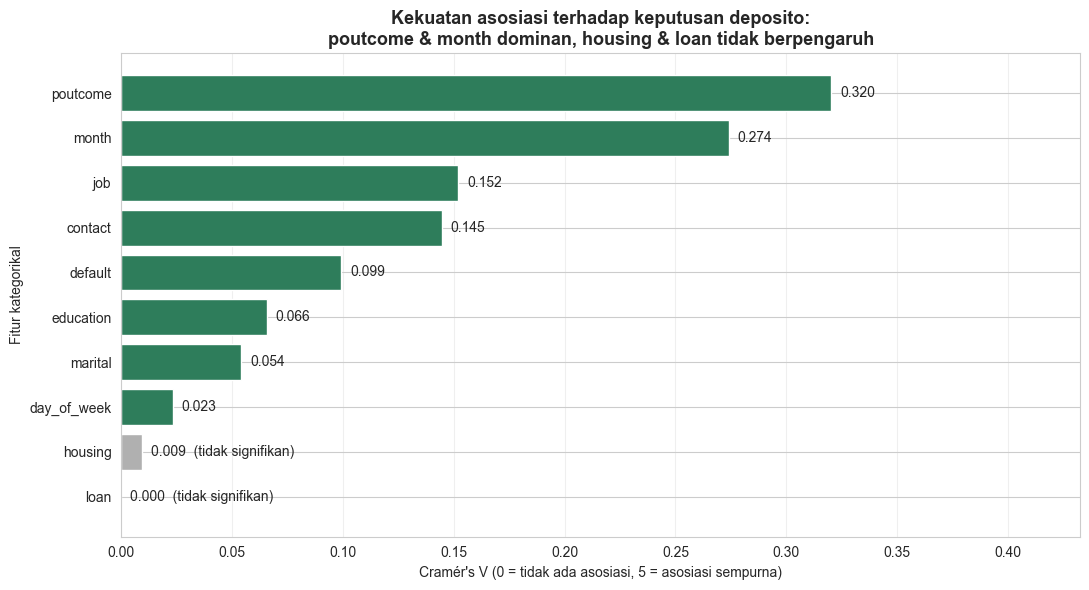

,feature,chi2_stat,p_value,cramers_v,kekuatan,kesimpulan
0,poutcome,4230.140000,0.000e+00,0.320400,kuat,Tolak H0 (Ada hubungan)
1,month,3103.030000,0.000e+00,0.274100,kuat,Tolak H0 (Ada hubungan)
2,job,961.740000,3.268e-199,0.152000,sedang,Tolak H0 (Ada hubungan)
3,contact,862.080000,1.719e-189,0.144600,sedang,Tolak H0 (Ada hubungan)
4,default,406.560000,5.218e-89,0.099100,lemah,Tolak H0 (Ada hubungan)
5,education,175.800000,2.647e-35,0.065600,lemah,Tolak H0 (Ada hubungan)
6,marital,122.960000,1.778e-26,0.054000,lemah,Tolak H0 (Ada hubungan)
7,day_of_week,26.050000,3.086e-05,0.023100,sangat lemah,Tolak H0 (Ada hubungan)
8,housing,5.740000,5.664e-02,0.009500,sangat lemah,Gagal Tolak H0 (Tidak ada hubungan)
9,loan,1.100000,5.772e-01,0.000000,sangat lemah,Gagal Tolak H0 (Tidak ada hubungan)


In [59]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.values.sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min(kcorr - 1, rcorr - 1))

test['cramers_v'] = [round(cramers_v(df_clean[f], df_clean['y']), 4) for f in test['feature']]
test['kekuatan'] = pd.cut(test['cramers_v'], bins=[-1, .05, .10, .20, 1],
                         labels=['sangat lemah', 'lemah', 'sedang', 'kuat'])
test = test.sort_values('cramers_v', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6))
warna = np.where(test['p_value'] < 0.05, '#2E7D5B', '#B0B0B0')
ax.barh(test['feature'][::-1], test['cramers_v'][::-1], color=warna[::-1])
for i, (v, p) in enumerate(zip(test['cramers_v'][::-1], test['p_value'][::-1])):
    ax.text(v + .004, i, f"{v:.3f}" + ('' if p < 0.05 else '  (tidak signifikan)'),
            va='center', fontsize=10)
ax.set_xlabel("Cramér's V (0 = tidak ada asosiasi, 5 = asosiasi sempurna)")
ax.set_ylabel('Fitur kategorikal')
ax.set_xlim(0, test['cramers_v'].max() * 1.35)
ax.set_title("Kekuatan asosiasi terhadap keputusan deposito:\n"
             "poutcome & month dominan, housing & loan tidak berpengaruh",
             fontsize=13, weight='bold')
ax.grid(axis='x', alpha=.3)
plt.tight_layout(); plt.show()

display(test[['feature', 'chi2_stat', 'p_value', 'cramers_v', 'kekuatan', 'kesimpulan']]
        .style.format({'p_value': '{:.3e}'}))

**INSIGHT**

Dari 10 fitur kategorikal, 8 signifikan pada alpha = 0.05 dan 2 tidak. Peringkat kekuatan asosiasi dengan Cramer's V: `poutcome` 0.320 dan `month` 0.274 (kategori kuat), disusul `job` 0.152 dan `contact` 0.145 (sedang).

Temuan negatif yang justru berguna. `housing` (V = 0,010; p = 0,057) dan `loan`
(V = 0,000; p = 0,577) tidak berhubungan dengan keputusan deposito. Ini berlawanan dengan dugaan awal bahwa nasabah dengan cicilan KPR atau pinjaman pribadi punya lebih sedikit dana menganggur. Pada n sebesar 41.176 — di mana selisih sekecil apa pun biasanya lolos uji — kedua fitur tetap gagal signifikan, sehingga kesimpulannya cukup kuat: kepemilikan kredit tidak boleh dipakai sebagai dasar segmentasi kampanye.

Mengapa dua ukuran dilaporkan bersama? `day_of_week` signifikan (*p* = 3,1 x 10⁻⁵) tetapi Cramér's V-nya hanya **0,023** — praktis tanpa nilai bisnis. Ini contoh klasik signifikan secara statistik tetapi tidak berarti secara praktis, yang hanya terlihat bila ukuran efek ikut dilaporkan. Guideline secara khusus mengingatkan agar tingkat signifikansi tidak digeneralisasi tanpa pertimbangan, dan kasus ini memperlihatkan alasannya.

**Rekomendasi (Action)** 

Prioritaskan `poutcome`, `month`, `job`, dan `contact` sebagai tulang punggung aturan penargetan; keluarkan `housing` dan `loan` dari kriteria segmentasi manual. Untuk tahap modeling keduanya boleh tetap disertakan agar model sendiri yang memutuskan, tetapi tidak layak dijadikan dasar kebijakan bisnis.

### c. Siapa nasabah yang paling layak diprioritaskan

Tiga fitur profil nasabah didalami di sini: **`job`** (Cramér's V 0,152, terkuat), **`age`**, serta **`default`** karena kategori `unknown`-nya menentukan keputusan preprocessing.

In [47]:
# per pekerjaan
job_conv = df_clean.groupby('job')['y'].agg(['count', 'sum', 'mean'])
job_conv.columns = ['count', 'sum', 'conv_rate']
job_conv['conv_rate'] = (job_conv['conv_rate'] * 100).round(2)          # % nasabah berdeposito
job_conv['pct_volume'] = (job_conv['count'] / n_nasabah * 100).round(2) # share bebean panggilan
job_conv['pct_deposan'] = (job_conv['sum'] / n_deposan * 100).round(2)  # share hasil deposan per pekerjaan
job_conv['lift'] = (job_conv['conv_rate'] / baseline_rate).round(2)     # berapa kali lebih tinggi dari baseline

# per usia
age_conv = df_clean.groupby('age_group')['y'].agg(['count', 'sum', 'mean'])
age_conv.columns = ['count', 'sum', 'conv_rate']
age_conv['conv_rate'] = (age_conv['conv_rate'] * 100).round(2)          
age_conv['pct_volume'] = (age_conv['count'] / n_nasabah * 100).round(2) 
age_conv['pct_deposan'] = (age_conv['sum'] / n_deposan * 100).round(2)  
age_conv['lift'] = (age_conv['conv_rate'] / baseline_rate).round(2)     

/var/folders/r0/4lnkl5dn0yn1y1ttmn335r200000gn/T/ipykernel_13139/3913595366.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  job_conv = df_clean.groupby('job')['y'].agg(['count', 'sum', 'mean'])
/var/folders/r0/4lnkl5dn0yn1y1ttmn335r200000gn/T/ipykernel_13139/3913595366.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_conv = df_clean.groupby('age_group')['y'].agg(['count', 'sum', 'mean'])


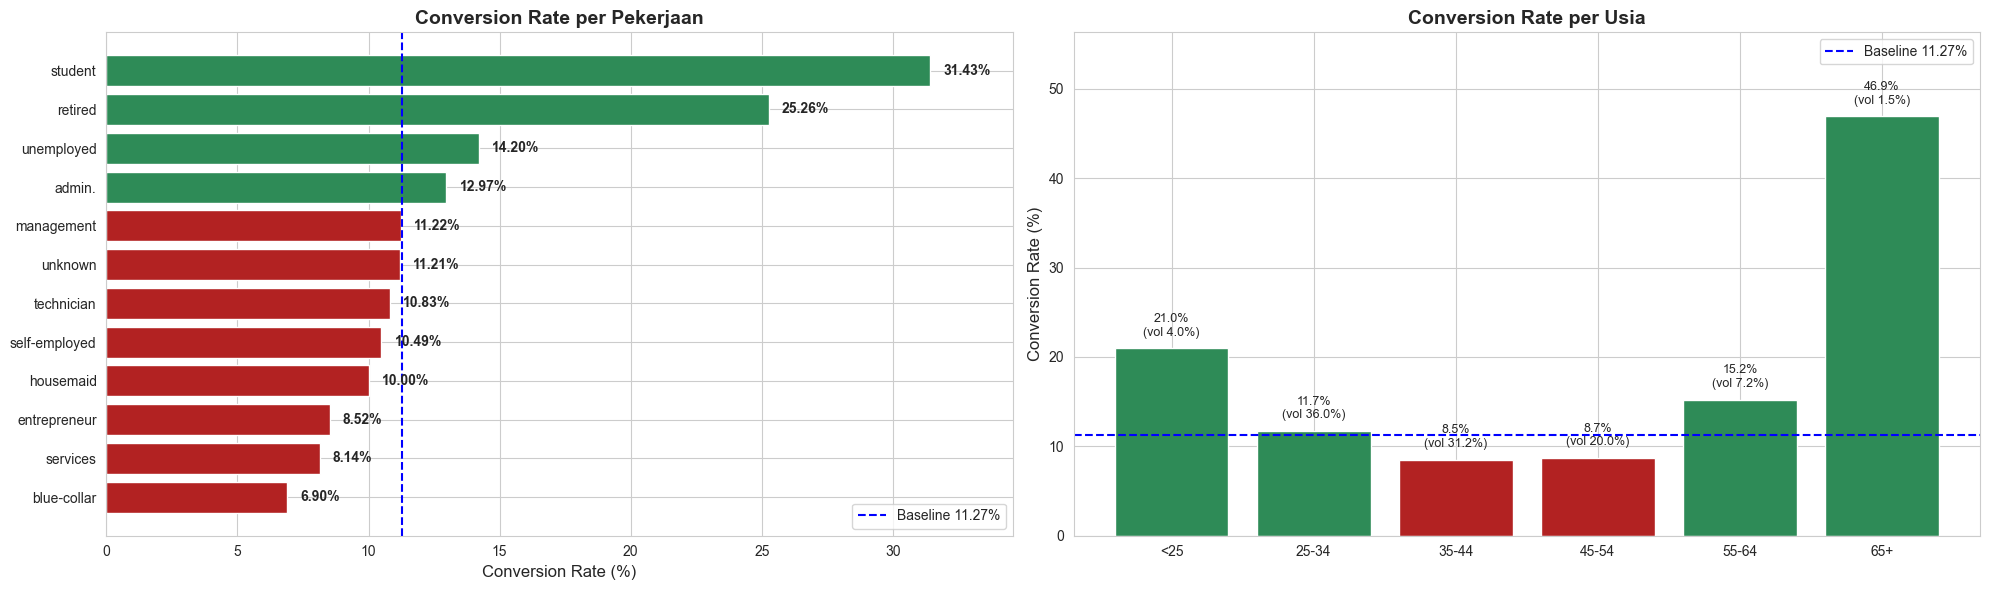

,count,sum,conv_rate,pct_volume,pct_deposan,lift
job,,,,,,
student,875,275,31.43,2.13,5.93,2.79
retired,1718,434,25.26,4.17,9.36,2.24
unemployed,1014,144,14.20,2.46,3.10,1.26
admin.,10419,1351,12.97,25.30,29.12,1.15
management,2924,328,11.22,7.10,7.07,1.00
unknown,330,37,11.21,0.80,0.80,1.00
technician,6739,730,10.83,16.37,15.74,0.96
self-employed,1421,149,10.49,3.45,3.21,0.93
housemaid,1060,106,10.00,2.57,2.28,0.89


,count,sum,conv_rate,pct_volume,pct_deposan,lift
age_group,,,,,,
<25,1665,349,20.96,4.04,7.52,1.86
25-34,14844,1740,11.72,36.05,37.51,1.04
35-44,12839,1092,8.51,31.18,23.54,0.76
45-54,8247,717,8.69,20.03,15.46,0.77
55-64,2963,451,15.22,7.20,9.72,1.35
65+,618,290,46.93,1.50,6.25,4.17


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

t = job_conv.sort_values('conv_rate')
axes[0].barh(t.index, t['conv_rate'], color=np.where(t['conv_rate'] >= baseline_rate, 'seagreen', 'firebrick'))
for i, v in enumerate(t['conv_rate']):
    axes[0].text(v + 0.5, i, f"{v:.2f}%", va='center', fontsize=10, weight="bold")
axes[0].axvline(baseline_rate, color='blue', linestyle='--', label=f'Baseline {baseline_rate:.2f}%')
axes[0].set_xlim(0, max(t['conv_rate'].max(), baseline_rate) * 1.1)
axes[0].set_title("Conversion Rate per Pekerjaan", fontsize=14, weight="bold")
axes[0].set_xlabel("Conversion Rate (%)", fontsize=12)
axes[0].legend()

t = age_conv
axes[1].bar(t.index.astype(str), t['conv_rate'], color=np.where(t['conv_rate'] >= baseline_rate, 'seagreen', 'firebrick'))
for i, (cr, pv) in enumerate(zip(t['conv_rate'], t['pct_volume'])):
    axes[1].text(i, cr + t['conv_rate'].max()*0.03, f'{cr:.1f}%\n(vol {pv:.1f}%)', ha='center', fontsize=9)
axes[1].set_ylim(0, max(t['conv_rate'].max(), baseline_rate) * 1.2)
axes[1].axhline(baseline_rate, color='blue', linestyle='--', label=f'Baseline {baseline_rate:.2f}%')
axes[1].set_title("Conversion Rate per Usia", fontsize=14, weight="bold")
axes[1].set_ylabel("Conversion Rate (%)", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

display(job_conv.sort_values('conv_rate', ascending=False))
display(age_conv)

In [49]:
job_conv.sort_values('conv_rate', ascending=False).head(10)

,count,sum,conv_rate,pct_volume,pct_deposan,lift
job,,,,,,
student,875,275,31.43,2.13,5.93,2.79
retired,1718,434,25.26,4.17,9.36,2.24
unemployed,1014,144,14.20,2.46,3.10,1.26
admin.,10419,1351,12.97,25.30,29.12,1.15
management,2924,328,11.22,7.10,7.07,1.00
unknown,330,37,11.21,0.80,0.80,1.00
technician,6739,730,10.83,16.37,15.74,0.96
self-employed,1421,149,10.49,3.45,3.21,0.93
housemaid,1060,106,10.00,2.57,2.28,0.89


Sekarang kira masuk ke uji inferensial: Apakah selisih antar segmen nyata atau variasi sampel? Disini kita akan menggunakan two-proportion z-test, karena target `y` merupakan binary (yes or no), jadi yang dibandingkan adalah proporsi deposan, bukan rata-rata, sehingga t-test tidak tepat. Dua kelompok yang dibandingkan saling bebas, dan setiap kelompok berisi ratusan sampai belasan ribu nasabah sehingga syarat aproksimasi normal (n*p >= 10) terpenuhi dengan aman. Berikut adalah hipotesis untuk uji:
- H0: proporsi deposan kedua kelompok sama (p1 = p2)
- H1: proporsi deposan kedua kelompok berbeda (p1 != p2)

H0 ditolak bila p-value < 0.05 

In [60]:
# Pelajar + pensiunan vs blue-collar
g1 = df_clean.loc[df_clean['job'].isin(['student', 'retired']), 'y']
g2 = df_clean.loc[df_clean['job'] == 'blue-collar', 'y']
n1, n2 = len(g1), len(g2)
p1, p2 = g1.mean(), g2.mean()
p_gab  = (g1.sum() + g2.sum()) / (n1 + n2)                          # proporsi gabungan (pooled)
z      = (p1 - p2) / np.sqrt(p_gab * (1 - p_gab) * (1/n1 + 1/n2))
p_val  = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"Pelajar + pensiunan ({p1*100:.2f}%, n={n1:,}) vs Blue-collar ({p2*100:.2f}%, n={n2:,})")
print(f"  selisih = {(p1-p2)*100:+.2f} poin persentase | z = {z:.2f} | p-value = {p_val:.3e}"
      f" | {'SIGNIFIKAN' if p_val < 0.05 else 'tidak signifikan'} pada alpha 5%\n")

# Usia > 60 tahun vs usia 35-44 tahun
g1 = df_clean.loc[df_clean['age'] > 60, 'y']
g2 = df_clean.loc[df_clean['age'].between(35, 44), 'y']
n1, n2 = len(g1), len(g2)
p1, p2 = g1.mean(), g2.mean()
p_gab  = (g1.sum() + g2.sum()) / (n1 + n2)
z      = (p1 - p2) / np.sqrt(p_gab * (1 - p_gab) * (1/n1 + 1/n2))
p_val  = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"Usia > 60 tahun ({p1*100:.2f}%, n={n1:,}) vs Usia 35-44 tahun ({p2*100:.2f}%, n={n2:,})")
print(f"  selisih = {(p1-p2)*100:+.2f} poin persentase | z = {z:.2f} | p-value = {p_val:.3e}"
      f" | {'SIGNIFIKAN' if p_val < 0.05 else 'tidak signifikan'} pada alpha 5%\n")

# Status kredit tidak diketahui vs diketahui
g1 = df_clean.loc[df_clean['default'] == 'unknown', 'y']
g2 = df_clean.loc[df_clean['default'] == 'no', 'y']
n1, n2 = len(g1), len(g2)
p1, p2 = g1.mean(), g2.mean()
p_gab  = (g1.sum() + g2.sum()) / (n1 + n2)
z      = (p1 - p2) / np.sqrt(p_gab * (1 - p_gab) * (1/n1 + 1/n2))
p_val  = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"default = 'unknown' ({p1*100:.2f}%, n={n1:,}) vs default = 'no' ({p2*100:.2f}%, n={n2:,})")
print(f"  selisih = {(p1-p2)*100:+.2f} poin persentase | z = {z:.2f} | p-value = {p_val:.3e}"
      f" | {'SIGNIFIKAN' if p_val < 0.05 else 'tidak signifikan'} pada alpha 5%\n")

Pelajar + pensiunan (27.34%, n=2,593) vs Blue-collar (6.90%, n=9,253)
  selisih = +20.45 poin persentase | z = 28.99 | p-value = 0.000e+00 | SIGNIFIKAN pada alpha 5%

Usia > 60 tahun (45.54%, n=909) vs Usia 35-44 tahun (8.66%, n=13,495)
  selisih = +36.89 poin persentase | z = 34.43 | p-value = 0.000e+00 | SIGNIFIKAN pada alpha 5%

default = 'unknown' (5.15%, n=8,596) vs default = 'no' (12.88%, n=32,577)
  selisih = -7.73 poin persentase | z = -20.15 | p-value = 0.000e+00 | SIGNIFIKAN pada alpha 5%



Hasilnya, ketiga perbandingan di atas signifikan, di mana pelajar + pensiunan mengungguli blue-collar, usia > 60 mengungguli usia 36–45, dan status kredit `unknown` tertinggal dari `no`.

Tetapi ada satu keterbatasan penting: kelompok-kelompok tersebut dibentuk oleh analis, bukan dari data. Garis potong "usia > 60" dan "usia 36-45" dipilih setelah melihat grafik. Uji proporsi baru bisa bekerja setelah garis potongnya ditetapkan, ia tidak dapat menjawab apakah usia itu sendiri, sebagai angka mentah tanpa dikelompokkan, membedakan deposan dari nono-deposan.

Pertanyaan itu butuh jenis uji yang berbeda dan inilah alasan peralihannya:
- Yang dibandingkan bukan proporsi lagi, melaiknkan sebaran angka. Bukan "berapa persen yang berdeposito di tiap kelompok", tetapi "apakah usia deposan cenderung berbeda dari usia non-deposan"
- Kenapa Mann-Whitney U, bukan t-test? t-test mensyaratkan data berdistribusi normal, sedangkan QQ-plot di section C menunjukkan `age` menceng kee kanan. Mann-Whitney membandingkan peringkat, sehingga asumsi normalitas tidak diperlukan.
- Hasil analisa yang akan dilakukan setelah ini sangat menentukan. Bila usia berhubungan secara monotonik (makin tua konversi makin tinggi, dan sebaliknya), `age` boleh dipakai langsung sebagai angka. Bila tidak, `age` wajib dikelompokkan. Grafik deskriptif tadi memperlihatkan pola berbentuk U, uji berikut yang membuktikannya secara statistik.


Berikut adalah hipotesis dari uji Mann-Whitney:
- H0: sebaran usia deposan = sebaran usia non-deposan
- H1: sebaran usia deposan != sebaran usia non-deposan 

H0 ditolak bila p-value < 0,05.

In [62]:
usia_deposan     = df_clean.loc[df_clean.y == 1, 'age']
usia_non_deposan = df_clean.loc[df_clean.y == 0, 'age']
u, p_val = stats.mannwhitneyu(usia_deposan, usia_non_deposan, alternative='two-sided')
rank_biserial = (2 * u) / (len(usia_deposan) * len(usia_non_deposan)) - 1   # ukuran besar efek

print('--- Mann-Whitney U pada `age` sebagai variabel kontinu (alpha = 5%) ---')
print(f"median usia deposan = {usia_deposan.median():.0f} th | "
      f"median usia non-deposan = {usia_non_deposan.median():.0f} th")
print(f"U = {u:,.0f} | p-value = {p_val:.3e} | rank-biserial = {rank_biserial:+.3f}")
print(f"  -> H0 ditolak pada alpha 5% (p = {p_val:.4f}), TETAPI rank-biserial {rank_biserial:+.3f}")
print("     menunjukkan besar efeknya nyaris nol, usia tidak berhubungan secara MONOTONIK.")
print("     Kesimpulan: `age` wajib dikelompokkan (binning), bukan dipakai sebagai angka mentah.")

--- Mann-Whitney U pada `age` sebagai variabel kontinu (alpha = 5%) ---
median usia deposan = 37 th | median usia non-deposan = 38 th
U = 82,905,028 | p-value = 1.564e-02 | rank-biserial = -0.022
  -> H0 ditolak pada alpha 5% (p = 0.0156), TETAPI rank-biserial -0.022
     menunjukkan besar efeknya nyaris nol, usia tidak berhubungan secara MONOTONIK.
     Kesimpulan: `age` wajib dikelompokkan (binning), bukan dipakai sebagai angka mentah.


**INSIGHT AKHIR**

Pelajar (31,43%) dan pensiunan (25,26%) memiliki conversion rate 2,79x dan 2,24x baseline, sedangkan blue-collar hanya 6,90% (lift 0,61x). Selisih pelajar + pensiunan terhadap blue-collar sebesar +20,45 poin persentase dan signifikan secara statistik (z = 28,99; p < 0,001), sehingga perbedaan ini bukan sekadar variasi sampel.

Dua kelompok paling produktif itu hanya menerima 6,3% panggilan (875 + 1.718 kontak), sementara blue-collar dan admin menyerap 47,8% panggilan (22,47% + 25,30%). Kapasitas telemarketing terbesar justru diarahkan ke segmen dengan hasil paling rendah.

Hubungan usia dengan konversi berbentuk U, bukan garis lurus. Konversi tertinggi ada pada kelompok usia tertua (46,93%, lift 4,17x) yang hanya menyerap 1,50% panggilan, disusul kelompok termuda (20,96%) dan kelompok 55-64 (15,22%). Titik terendahnya justru di kelompok 35-44 (8,51%) dan 45-54 8,69 — dua kelompok yang bersama-sama menyerap 51,21% seluruh panggilan. Perbandingan langsung nasabah usia > 60 tahun (45,54%) dengan usia 35-44 tahun (8,66%) memberi selisih +36,89 poin persentase (z = 34,43; p < 0,001).

Uji Mann-Whitney juga menegaskan bentuk U tersebut. Pada `age` sebagai variabel kontinu, rank-biserial hanya -0,022, nyaris nol, meskipun p-value-nya lolos alpha 5% (p = 0,0156). Uji monotonik memang tidak dirancang untuk menangkap hubungan berbentuk U: nasabah muda dan nasabah tua sama-sama berkonversi tinggi sehingga saling meniadakan ketika dibandingkan sebagai peringkat. Kesimpulannya, `age` wajib diperlakukan sebagai kelompok (binning), bukan sebagai variabel numerik linear. Lolosnya ambang 5% tidak berarti apa-apa ketika ukuran efeknya praktis nol.

Nasabah dengan `default = 'unknown'` hanya berkonversi 5,15%, sementara `default = 'no'` mencapai 12,88%. Selisih -7,73 poin persentase ini signifikan kuat (z = -20,15; p < 0,001) dan mencakup 20,88% populasi (8.596 dari 41.176 nasabah). Ketidaksediaan nasabah mengungkap status kreditnya ternyata merupakan sinyal negatif yang nyata, bukan derau. Inilah yang membenarkan keputusan mempertahankan `unknown` sebagai kategori tersendiri pada tahap preprocessing: bila diimputasi dengan modus `'no'`, 8.596 nasabah berkonversi rendah akan dilebur ke kelompok berkonversi tinggi dan sinyal senilai 7,73 poin persentase hilang begitu saja.

Sebagai dukungan secara teori, sisi usia tua dari pola U ini sejalan dengan *life-ccle hypothesis* dikemukakan oleh Franco Modigliani tahun 1957 (https://www.economicshelp.org/blog/27080/concepts/life-cycle-hypothesis/): Rumah tangga menabung selama masa produktif dan kekayaannya memuncak menjelang pensiun. Kelompok usia pensiun karena itu adalah yang paling mungkin memiliki dana menganggur untuk ditempatkan pada deposito berjangka.

**Rekomendasi**

Susun *call list* harian dengan kuota minimum untuk segmen pensiunan (usia > 60) dan pelajar; turunkan porsi blue-collar usia 35-54 yang saat ini mendominasi antrean. Tempatkan nasabah berstatus kredit `unknown` pada prioritas terendah, atau verifikasi datanya lebih dulu oleh tim data sebelum masuk antrean panggilan.

**Estimasi dampak**

Setiap 1.000 panggilan yang dialihkan dari profil usia 35-44 tahun (8,66%) ke profil usia > 60 tahun (45,54%) berpotensi menambah ±369 deposan tanpa menambah kapasitas (selisih 36,89 pp).

> NOTE: Segmen usia > 60 pada kampanye ini hanya berisi 909 nasabah dan seluruhnya sudah dihubungi, sehingga realokasi hanya mungkin bila basis nasabah bank masih menyimpan nasabah lansia yang belum tersentuh. Angka di atas adalah potensi per 1.000 panggilan, bukan total yang dijamin tercapai.

### d. Kapan waktu terbaik untuk menghubungi nasabah?

In [64]:
urut_bulan = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

bulan_conv = df_clean.groupby('month')['y'].agg(['count', 'sum', 'mean'])
bulan_conv.columns = ['count', 'sum', 'conv_rate']
bulan_conv['conv_rate'] = (bulan_conv['conv_rate'] * 100).round(2)          
bulan_conv['pct_volume'] = (bulan_conv['count'] / n_nasabah * 100).round(2) 
bulan_conv['pct_deposan'] = (bulan_conv['sum'] / n_deposan * 100).round(2)
bulan_conv['lift'] = (bulan_conv['conv_rate'] / baseline_rate).round(2)
bulan_conv = bulan_conv.reindex(urut_bulan)

/var/folders/r0/4lnkl5dn0yn1y1ttmn335r200000gn/T/ipykernel_13139/1720397194.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bulan_conv = df_clean.groupby('month')['y'].agg(['count', 'sum', 'mean'])


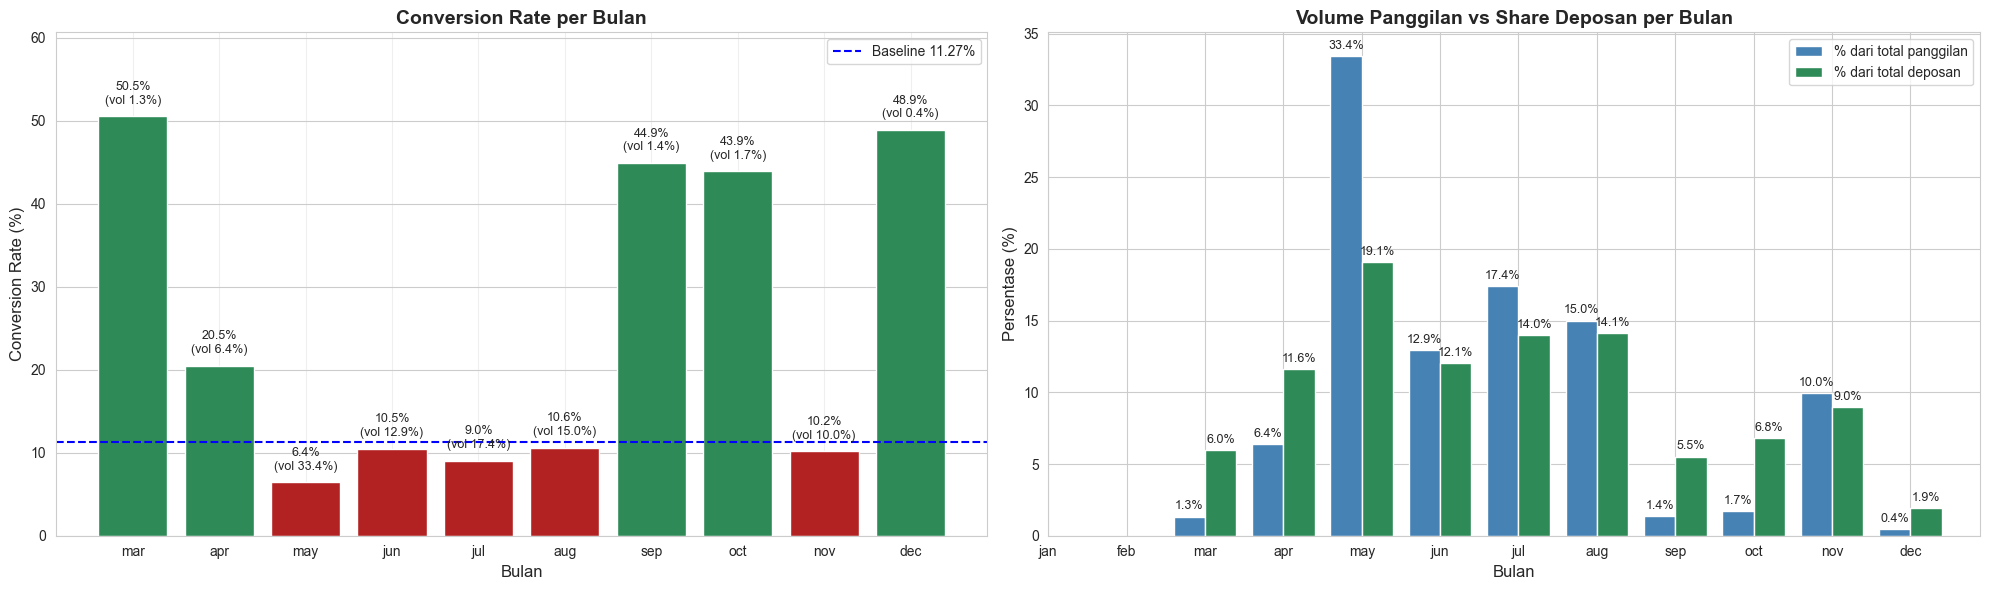

,count,sum,conv_rate,pct_volume,pct_deposan,lift,efisiensi
month,,,,,,,
mar,546.0,276.0,50.55,1.33,5.95,4.49,4.47
dec,182.0,89.0,48.90,0.44,1.92,4.34,4.36
sep,570.0,256.0,44.91,1.38,5.52,3.99,4.00
oct,717.0,315.0,43.93,1.74,6.79,3.90,3.90
apr,2631.0,539.0,20.49,6.39,11.62,1.82,1.82
aug,6176.0,655.0,10.61,15.00,14.12,0.94,0.94
jun,5318.0,559.0,10.51,12.92,12.05,0.93,0.93
nov,4100.0,416.0,10.15,9.96,8.97,0.90,0.90
jul,7169.0,648.0,9.04,17.41,13.97,0.80,0.80


In [71]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

## Conversion Rate per Bulan
t = bulan_conv
axes[0].bar(t.index.astype(str), t['conv_rate'], color=np.where(t['conv_rate'] > baseline_rate, 'seagreen', 'firebrick'))
for i, (cr, pv) in enumerate(zip(t['conv_rate'], t['pct_volume'])):
    axes[0].text(i, cr + t['conv_rate'].max()*0.03, f'{cr:.1f}%\n(vol {pv:.1f}%)', ha='center', fontsize=9)
axes[0].axhline(baseline_rate, color='blue', linestyle='--', label=f'Baseline {baseline_rate:.2f}%')
axes[0].set_ylim(0, max(t['conv_rate'].max(), baseline_rate) * 1.2)
axes[0].set_xlabel("Bulan", fontsize=12)
axes[0].set_ylabel("Conversion Rate (%)", fontsize=12)
axes[0].set_title("Conversion Rate per Bulan", fontsize=14, weight="bold")  
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

## Volume vs Share Deposan
x = np.arange(len(bulan_conv))
lebar = 0.4
axes[1].bar(x - lebar/2, bulan_conv['pct_volume'], width=lebar, label='% dari total panggilan', color='steelblue')
axes[1].bar(x + lebar/2, bulan_conv['pct_deposan'], width=lebar, label='% dari total deposan', color='seagreen')
for i, (vol, share) in enumerate(zip(bulan_conv['pct_volume'], bulan_conv['pct_deposan'])):
    axes[1].text(i - lebar/2, vol + 0.5, f'{vol:.1f}%', ha='center', fontsize=9)
    axes[1].text(i + lebar/2, share + 0.5, f'{share:.1f}%', ha='center', fontsize=9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(bulan_conv.index)
axes[1].set_xlabel("Bulan", fontsize=12)
axes[1].set_ylabel("Persentase (%)", fontsize=12)
axes[1].set_title("Volume Panggilan vs Share Deposan per Bulan", fontsize=14, weight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

bulan_conv['efisiensi'] = (bulan_conv['pct_deposan'] / bulan_conv['pct_volume']).round(2)
display(bulan_conv.sort_values('conv_rate', ascending=False))

Sekarang kita akan lanjut ke bagian analisa inferensial untuk melihat perbandingan: apakah conversion rate empat bulan tertinggi (Maret, September, Oktober, Desember) benar-benar berbeda dari bulan Mei (terendah)? Keempat bulan tersebut dikelompokkan sebagai "bulan emas" karena conversion ratenya yang sangat tinggi, tapi setelah Oktober rate anjlok di april sebesar 20%-an. Mei memiliki jumlah konversi yang terendah, tetapi juga memiliki volume panggilan yang paling tinggi dari semua bulan. 

Dalam analisis ini, kita akan menggunakan two-proportion z-test karena sama seperti bagian c, kita ingin membandingkan dua kelompok kategorikal yang berbeda. Berikut adalah hipotesis uji:
- H0: Conversion rate bulan emas = Conversion rate bulan terendah
- H1: Conversion rate bulan emas != Conversion rate bulan terendah 

H0 ditolak bila alpha < 0.05

In [79]:
# Inferensial Analysis
bulan_emas = bulan_conv.index[bulan_conv['lift'] >= 3].tolist()     # lift >= 3x baseline
terendah = bulan_conv['conv_rate'].idxmin()                       # bulan berkonversi terendah
assert terendah == bulan_conv['pct_volume'].idxmax(), 'pembanding harus sekaligus volume terbesar'

print(f"Bulan emas      : {bulan_emas} (konversi >= 3x baseline)")
print(f"Bulan terendah  : '{terendah}' ({bulan_conv.loc[terendah, 'conv_rate']:.2f}%) sekaligus volume TERBESAR ({bulan_conv.loc[terendah, 'pct_volume']:.2f}%)\n")

# Signifikansi perbedaan konversi bulan emas vs bulan terendah
g1 = df_clean.loc[df_clean['month'].isin(bulan_emas), 'y']
g2 = df_clean.loc[df_clean['month'] == terendah, 'y']
n1, n2 = len(g1), len(g2)
p1, p2 = g1.mean(), g2.mean()
p_gab  = (g1.sum() + g2.sum()) / (n1 + n2)
z      = (p1 - p2) / np.sqrt(p_gab * (1 - p_gab) * (1/n1 + 1/n2))
p_val  = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"Bulan emas (Mar/Sep/Okt/Des) ({p1*100:.2f}%, n={n1:,}) vs "
      f"Mei ({p2*100:.2f}%, n={n2:,})")
print(f"  selisih = {(p1-p2)*100:+.2f} poin persentase | z = {z:.2f} | p-value = {p_val:.3e}"
      f" | {'SIGNIFIKAN' if p_val < 0.05 else 'tidak signifikan'} pada alpha 5%\n")

# Perbandingan beban panggilan vs hasil pada kedua periode
emas = df_clean[df_clean['month'].isin(bulan_emas)]
mei  = df_clean[df_clean['month'] == terendah]
print(f"Bulan emas : {len(emas):,} panggilan ({len(emas)/n_nasabah*100:.2f}% volume) "
      f"-> {emas['y'].sum():,} deposan ({emas['y'].sum()/n_deposan*100:.2f}% dari total deposan)")
print(f"Mei        : {len(mei):,} panggilan ({len(mei)/n_nasabah*100:.2f}% volume) "
      f"-> {mei['y'].sum():,} deposan ({mei['y'].sum()/n_deposan*100:.2f}% dari total deposan)")


Bulan emas      : ['mar', 'sep', 'oct', 'dec'] (konversi >= 3x baseline)
Bulan terendah  : 'may' (6.44%) sekaligus volume TERBESAR (33.43%)

Bulan emas (Mar/Sep/Okt/Des) (46.45%, n=2,015) vs Mei (6.44%, n=13,767)
  selisih = +40.02 poin persentase | z = 52.50 | p-value = 0.000e+00 | SIGNIFIKAN pada alpha 5%

Bulan emas : 2,015 panggilan (4.89% volume) -> 936 deposan (20.18% dari total deposan)
Mei        : 13,767 panggilan (33.43% volume) -> 886 deposan (19.10% dari total deposan)


**INSIGHT AKHIR**

Bulan-bulan emas, yaitu **Maret (50,55%)**, **Desember (48,90%)**, **September (44,91%)**, dan **Oktober (43,93%)** memiliki rating konversi yang terbesar, sekitar 4x dari rata-rata konversi. Jika jumlah panggilan dari keempat bulan digabung, mereka hanya menerima 4,89% dari total panggilan dan hanya 20,18% dari seluruh deposan.

Dibandingkan dengan bulan Mei, rating konversi yang paling rendah (6.44%), menyerap 33,43% dari total panggilan dan menghasilkna 19,10% dari seluruh deposan. Artinya Mei memakai 6,8x lebih banyak panggilan daripada keempat bulan emas digabung, untuk jumlah deposan yang justru lebih sedikit. Selisih +40.02 poin persentasa antara bulan emas dan Mei signifikan sangat kuat (p < 0,001).

**Rekomendasi**

Susun ulang kalender kampanye dengna mnaikkan kapasitas panggilan pada bulan-bulan emas (Maret, September, Oktober, dan Desember), menurunkan konsentrasi panggilan massal di bulan Mei. Sebelum diterapkan penuh, jalankan uji A/B terkontrol pada bulan Mei (kelompok kontrol dihubungi seperti biasa vs kelompok uji ditunda ke bulan emas) untuk memastikan efeknya bersifat kausal dan bukan bias.

**Estimasi dampak**

Bila 20% panggilan Mei direalokasi ke bulan-bulan emas, selisih konversi +40,02 pp setara potensi tambahan sekitas 1102 deposan tanpa menambah kapasitas tim

> Catatan: Bulan emas saat ini hanya menerima 2.015 panggilan, sehingga realokasi ini akan melipatduakan volumenya. Konversi 46,45% hampir pasti akan menurun seiring bertambahnya volume (*diminishing returns*), karena prospek terbaik habis lebih dulu. Angka 1.102 karena itu merupakan batas atas optimistis, bukan target.



### e. Konteks Makroekonomi di balik pola musiman 

Sekarang, kita akan mulai memeriksa sebaran angka pada kolom-kolom makroekonomik pada `euribor3m`, `nr_employed`, dan `emp_var_rate`. Pertanyaan yang akan kita jawab dalam analisa ini adalah: Pada tingkat suku bunga seperti apa nasabah paling reseptif?

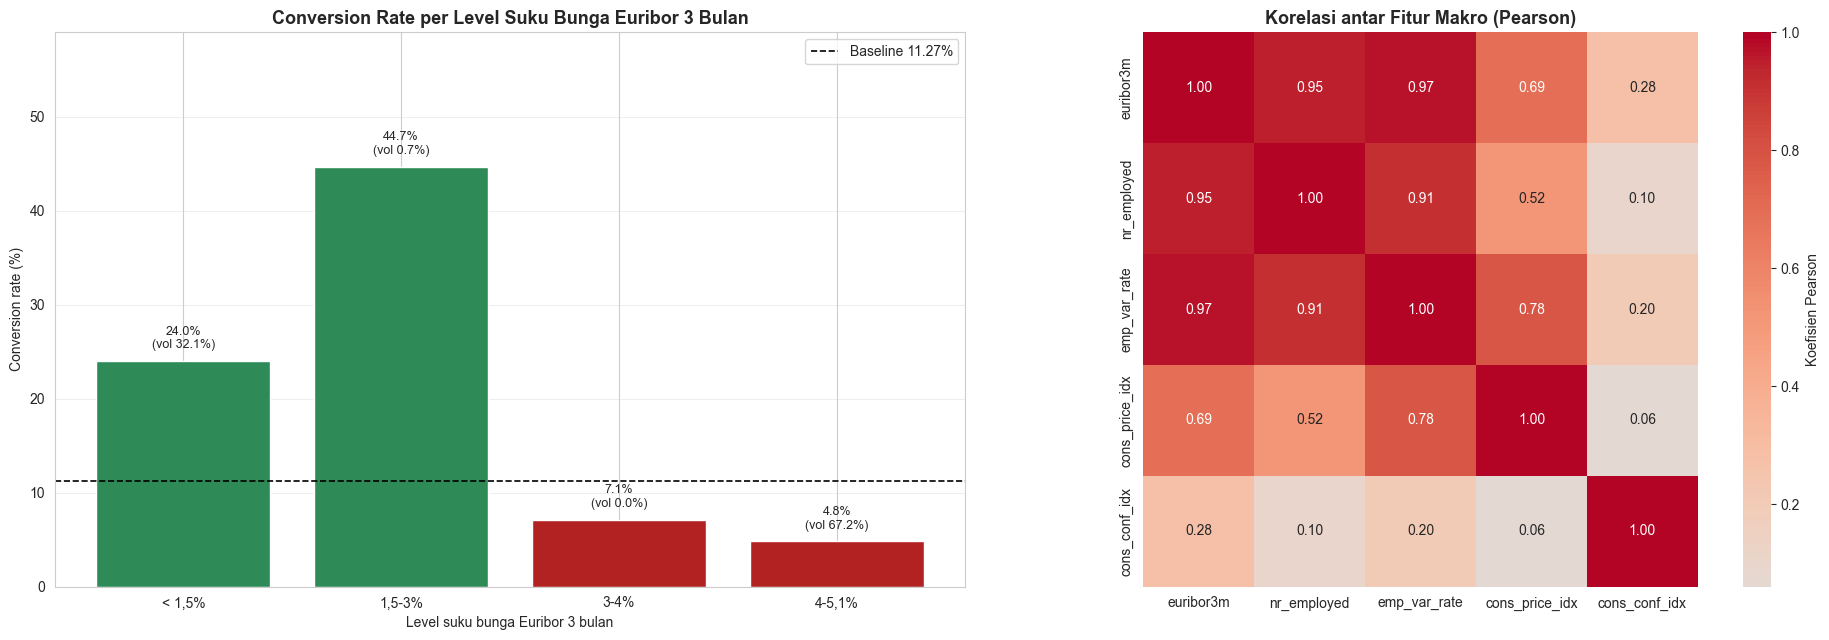

,volume,deposan,conv_rate,pct_volume,pct_deposan,lift
level_euribor,,,,,,
"< 1,5%",13212,3174,24.02,32.09,68.42,2.13
"1,5-3%",282,126,44.68,0.68,2.72,3.97
3-4%,14,1,7.14,0.03,0.02,0.63
"4-5,1%",27668,1338,4.84,67.19,28.84,0.43


In [85]:
df_clean['level_euribor'] = pd.cut(
    df_clean['euribor3m'], bins=[0, 1.5, 3, 4, 5.1],
    labels=['< 1,5%', '1,5-3%', '3-4%', '4-5,1%'])

eur_conv = df_clean.groupby('level_euribor', observed=True)['y'].agg(
    volume='count', deposan='sum', conv_rate='mean')
eur_conv['conv_rate']   = (eur_conv['conv_rate'] * 100).round(2)
eur_conv['pct_volume']  = (eur_conv['volume']  / n_nasabah * 100).round(2)
eur_conv['pct_deposan'] = (eur_conv['deposan'] / n_deposan * 100).round(2)
eur_conv['lift']        = (eur_conv['conv_rate'] / baseline_rate).round(2)

fig, axes = plt.subplots(1, 2, figsize=(19, 6.5))

# Konversi per level suku bunga
t = eur_conv
axes[0].bar(t.index.astype(str), t['conv_rate'],
            color=np.where(t['conv_rate'] > baseline_rate, 'seagreen', 'firebrick'))
axes[0].axhline(baseline_rate, ls='--', c='black', lw=1.2, label=f'Baseline {baseline_rate:.2f}%')
for i, (cr, pv) in enumerate(zip(t['conv_rate'], t['pct_volume'])):
    axes[0].text(i, cr + t['conv_rate'].max()*0.03, f'{cr:.1f}%\n(vol {pv:.1f}%)',
                 ha='center', fontsize=9)
axes[0].set_ylim(0, t['conv_rate'].max() * 1.32)
axes[0].set_xlabel('Level suku bunga Euribor 3 bulan')
axes[0].set_ylabel('Conversion rate (%)')
axes[0].set_title('Conversion Rate per Level Suku Bunga Euribor 3 Bulan',
                  fontsize=13, weight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=.3)

# Korelasi antar fitur makro (cek multikolinearitas)
makro = ['euribor3m', 'nr_employed', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx']
sns.heatmap(df_clean[makro].corr().round(2), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[1], cbar_kws={'label': 'Koefisien Pearson'})
axes[1].set_title('Korelasi antar Fitur Makro (Pearson)',
                  fontsize=13, weight='bold')
plt.tight_layout()

plt.show()
display(eur_conv)

Sekarang kita akan lanjut ke bagian analisa inferensial. Berbeda dari bagian sebelumnya, ketiga kolom yang diperiksa di sini (`euribor3m`, `nr_employed`, `emp_var_rate`) seluruhnya numerik, bukan kategori. Karena itu tidak ada proporsi yang bisa dibandingkan dengan z-test; yang dibandingkan adalah sebaran angkanya, yaitu apakah kondisi makroekonomi saat deposan dihubungi memang berbeda dari saat non-deposan dihubungi.

Uji yang dipakai adalah Mann-Whitney U, bukan t-test, karena ketiga variabel makro jauh dari normal. `nr_employed` hanya punya 11 nilai unik dan `emp_var_rate` hanya 10 nilai unik, sebab keduanya bergerak mengikuti rilis indikator ekonomi kuartalan dan bukan berbentuk lonceng. Mann-Whitney membandingkan peringkat, sehingga asumsi normalitas tidak diperlukan. Selain p-value, kita juga melaporkan rank-biserial sebagai ukuran besar efek (rentang -1 sampai +1).

Berikut adalah hipotesis uji:
- H0: Sebaran kondisi makro saat deposan dihubungi = saat non-deposan dihubungi
- H1: Sebaran kondisi makro saat deposan dihubungi != saat non-deposan dihubungi

H0 ditolak bila p-value < 0.05

In [86]:
# Inferensial Analysis
print('Mann-Whitney U: kondisi makro saat deposan vs non-deposan dihubungi\n')
for kolom in ['euribor3m', 'nr_employed', 'emp_var_rate']:
    a = df_clean.loc[df_clean['y'] == 1, kolom]
    b = df_clean.loc[df_clean['y'] == 0, kolom]
    u, p_val = stats.mannwhitneyu(a, b, alternative='two-sided')
    rank_biserial = (2 * u) / (len(a) * len(b)) - 1
    print(f"{kolom:15s} median deposan = {a.median():9.3f} | non-deposan = {b.median():9.3f} | "
          f"p-value = {p_val:.3e} | rank-biserial = {rank_biserial:+.3f}")

Mann-Whitney U: kondisi makro saat deposan vs non-deposan dihubungi

euribor3m       median deposan =     1.266 | non-deposan =     4.857 | p-value = 0.000e+00 | rank-biserial = -0.487
nr_employed     median deposan =  5099.100 | non-deposan =  5195.800 | p-value = 0.000e+00 | rank-biserial = -0.498
emp_var_rate    median deposan =    -1.800 | non-deposan =     1.100 | p-value = 0.000e+00 | rank-biserial = -0.433


**INSIGHT AKHIR**

Ketika Euribor 3 bulan turun di bawah 1,5%, conversion rate melonjak ke **24,02%** (lift 2,13x). Sebaliknya pada masa suku bunga tinggi (4-5,1%) konversinya hanya **4,84%** (lift 0,43x), padahal periode itu justru menyerap **67,19%** dari seluruh panggilan. Selisihnya hampir 5x lipat.

Uji Mann-Whitney memperkuat hal tersebut. Median Euribor saat deposan dihubungi adalah **1,266%**, sedangkan saat non-deposan dihubungi **4,857%**. Rank-biserial-nya **-0,487** untuk `euribor3m` dan **-0,498** untuk `nr_employed`, yang merupakan **efek terkuat di seluruh dataset**, jauh melampaui efek variabel demografis mana pun yang sudah kita periksa di bagian c dan d.

Artinya, faktor eksternal berupa kondisi ekonomi lebih menentukan keberhasilan kampanye daripada kualitas skrip telemarketing. Saat suku bunga acuan rendah, instrumen berisiko rendah seperti deposito berjangka menjadi jauh lebih menarik bagi nasabah, sehingga mereka lebih reseptif terhadap tawaran bank.

**Implikasi untuk pemodelan**

Panel kanan memperlihatkan korelasi antar fitur makro mencapai **0,97** (`euribor3m` vs `emp_var_rate`). Memasukkan kelimanya sekaligus ke model linear akan membuat koefisien tidak stabil dan feature importance menyesatkan, jadi sebaiknya pilih salah satu wakil saja atau gunakan reduksi dimensi. Selain itu, karena variabel makro begitu dominan, model yang dilatih pada data ini berpeluang gagal ketika rezim suku bunga berubah, sehingga model sebaiknya dipandang sebagai alat pengurut prioritas relatif, bukan penaksir probabilitas absolut yang berlaku lintas waktu.

**Rekomendasi**

Jadikan level Euribor sebagai pemicu intensitas kampanye. Saat suku bunga acuan turun di bawah 1,5%, tingkatkan kapasitas telemarketing secara agresif; saat suku bunga tinggi, alihkan sumber daya ke produk lain dan kurangi volume panggilan deposito. Lakukan juga pelatihan ulang model minimal setiap kuartal dengan pemantauan drift.

> Catatan: kelompok `1,5-3%` dan `3-4%` masing-masing hanya berisi 282 dan 14 nasabah, sehingga conversion rate keduanya tidak dapat digeneralisasi. Perbandingan yang layak dipakai hanya antara kelompok `< 1,5%` dan `4-5,1%` yang sama-sama bervolume besar.

### f. Melalui kanal apa dan berapa kali nasabah layak dihubungi?

Setelah mengetahui siapa yang layak dihubungi dan kapan waktunya, sekarang kita periksa caranya. Pertanyaan yang akan kita jawab dalam analisa ini adalah: kanal kontak mana yang paling efektif, dan sampai panggilan ke berapa konversi masih bertahan?

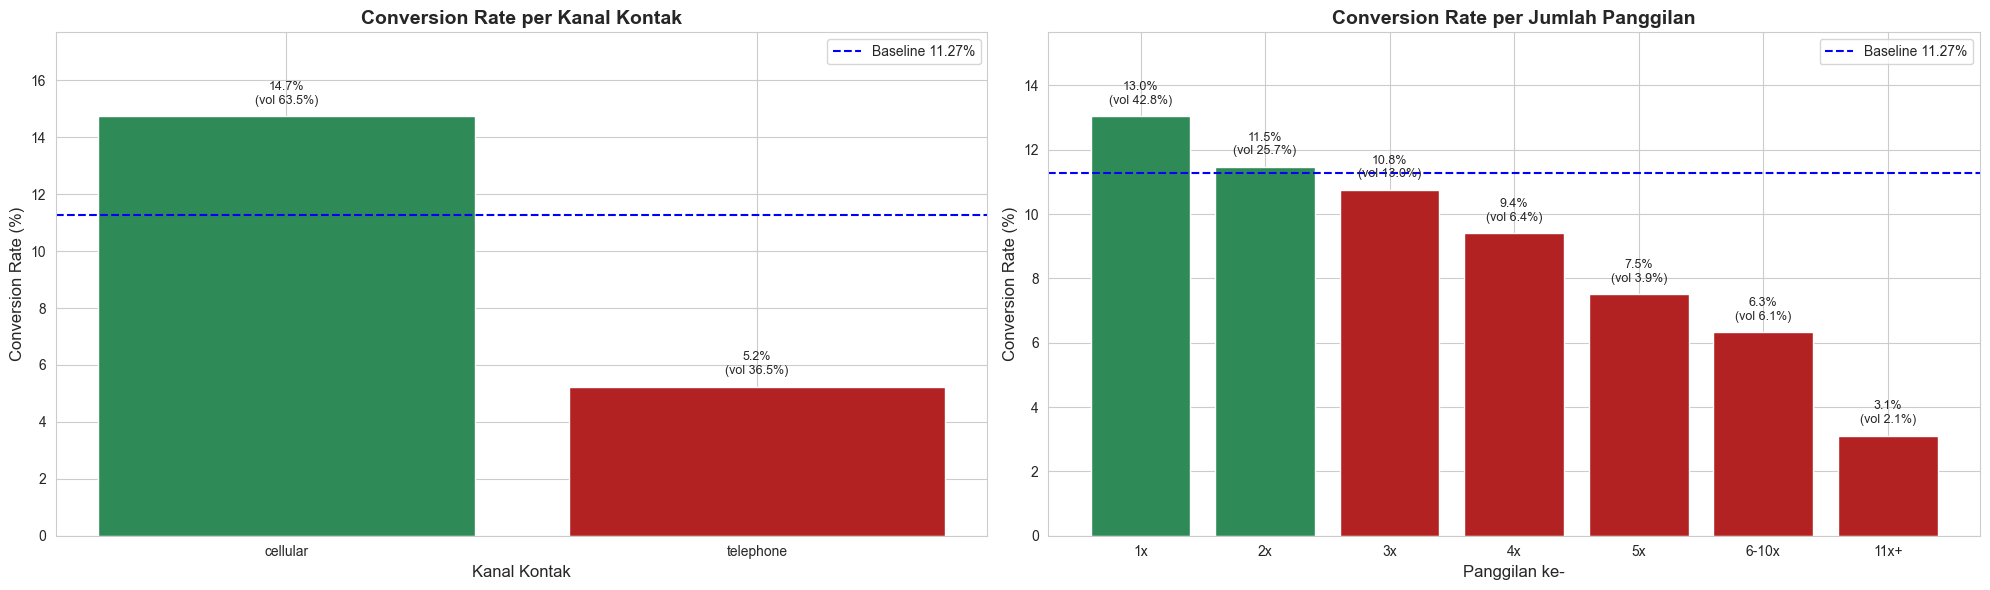

,count,sum,conv_rate,pct_volume,pct_deposan,lift
contact,,,,,,
cellular,26135,3852,14.74,63.47,83.04,1.31
telephone,15041,787,5.23,36.53,16.96,0.46


,count,sum,conv_rate,pct_volume,pct_deposan,lift
urutan_panggilan,,,,,,
1x,17634,2299,13.04,42.83,49.56,1.16
2x,10568,1211,11.46,25.67,26.10,1.02
3x,5340,574,10.75,12.97,12.37,0.95
4x,2650,249,9.40,6.44,5.37,0.83
5x,1599,120,7.50,3.88,2.59,0.67
6-10x,2516,159,6.32,6.11,3.43,0.56
11x+,869,27,3.11,2.11,0.58,0.28


In [87]:
# Tabel ringkas kanal kontak
kanal_conv = df_clean.groupby('contact', observed=True)['y'].agg(['count', 'sum', 'mean'])
kanal_conv.columns = ['count', 'sum', 'conv_rate']
kanal_conv['conv_rate'] = (kanal_conv['conv_rate'] * 100).round(2)
kanal_conv['pct_volume'] = (kanal_conv['count'] / n_nasabah * 100).round(2)
kanal_conv['pct_deposan'] = (kanal_conv['sum'] / n_deposan * 100).round(2)
kanal_conv['lift'] = (kanal_conv['conv_rate'] / baseline_rate).round(2)

# Kolom turunan: nasabah ini dihubungi berapa kali pada kampanye berjalan
df_clean['urutan_panggilan'] = pd.cut(df_clean['campaign'],
                                      bins=[0, 1, 2, 3, 4, 5, 10, 100],
                                      labels=['1x', '2x', '3x', '4x', '5x', '6-10x', '11x+'])
urut_conv = df_clean.groupby('urutan_panggilan', observed=True)['y'].agg(['count', 'sum', 'mean'])
urut_conv.columns = ['count', 'sum', 'conv_rate']
urut_conv['conv_rate'] = (urut_conv['conv_rate'] * 100).round(2)
urut_conv['pct_volume'] = (urut_conv['count'] / n_nasabah * 100).round(2)
urut_conv['pct_deposan'] = (urut_conv['sum'] / n_deposan * 100).round(2)
urut_conv['lift'] = (urut_conv['conv_rate'] / baseline_rate).round(2)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

## Conversion Rate per Kanal Kontak
t = kanal_conv
axes[0].bar(t.index.astype(str), t['conv_rate'],
            color=np.where(t['conv_rate'] > baseline_rate, 'seagreen', 'firebrick'))
for i, (cr, pv) in enumerate(zip(t['conv_rate'], t['pct_volume'])):
    axes[0].text(i, cr + t['conv_rate'].max()*0.03, f'{cr:.1f}%\n(vol {pv:.1f}%)', ha='center', fontsize=9)
axes[0].axhline(baseline_rate, color='blue', linestyle='--', label=f'Baseline {baseline_rate:.2f}%')
axes[0].set_ylim(0, max(t['conv_rate'].max(), baseline_rate) * 1.2)
axes[0].set_xlabel("Kanal Kontak", fontsize=12)
axes[0].set_ylabel("Conversion Rate (%)", fontsize=12)
axes[0].set_title("Conversion Rate per Kanal Kontak", fontsize=14, weight="bold")
axes[0].legend()

## Conversion Rate per Urutan Panggilan
t = urut_conv
axes[1].bar(t.index.astype(str), t['conv_rate'],
            color=np.where(t['conv_rate'] > baseline_rate, 'seagreen', 'firebrick'))
for i, (cr, pv) in enumerate(zip(t['conv_rate'], t['pct_volume'])):
    axes[1].text(i, cr + t['conv_rate'].max()*0.03, f'{cr:.1f}%\n(vol {pv:.1f}%)', ha='center', fontsize=9)
axes[1].axhline(baseline_rate, color='blue', linestyle='--', label=f'Baseline {baseline_rate:.2f}%')
axes[1].set_ylim(0, max(t['conv_rate'].max(), baseline_rate) * 1.2)
axes[1].set_xlabel("Panggilan ke-", fontsize=12)
axes[1].set_ylabel("Conversion Rate (%)", fontsize=12)
axes[1].set_title("Conversion Rate per Jumlah Panggilan", fontsize=14, weight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

display(kanal_conv)
display(urut_conv)

Sekarang kita masuk ke bagian inferensial. Bagian ini memakai dua jenis uji karena pertanyaannya memang berbeda.

Dua uji pertama membandingkan proporsi deposan antar kelompok, jadi memakai two-proportion z-test seperti bagian c dan d. Uji ketiga berbeda: yang dibandingkan bukan proporsi, melainkan sebaran angka jumlah panggilan pada deposan versus non-deposan. Karena `campaign` sangat menceng ke kanan (terlihat dari QQ-plot di bagian EDA), asumsi normalitas t-test tidak terpenuhi, sehingga kita memakai Mann-Whitney U. Uji ketiga ini dibuat satu arah sebab hipotesisnya berarah: dugaan kita deposan dihubungi lebih sedikit, bukan sekadar berbeda.

Berikut adalah hipotesis ketiga uji:
- Uji 1 — H0: Conversion rate cellular = telephone | H1: berbeda (dua arah)
- Uji 2 — H0: Conversion rate panggilan ke-1 s/d ke-3 = panggilan ke-4 ke atas | H1: berbeda (dua arah)
- Uji 3 — H0: Sebaran jumlah panggilan deposan = non-deposan | H1: deposan dihubungi lebih sedikit (satu arah)

H0 ditolak bila p-value < 0.05

In [88]:
# Inferensial Analysis
# Uji 1: Cellular vs Telephone
g1 = df_clean.loc[df_clean['contact'] == 'cellular', 'y']
g2 = df_clean.loc[df_clean['contact'] == 'telephone', 'y']
n1, n2 = len(g1), len(g2)
p1, p2 = g1.mean(), g2.mean()
p_gab  = (g1.sum() + g2.sum()) / (n1 + n2)
z      = (p1 - p2) / np.sqrt(p_gab * (1 - p_gab) * (1/n1 + 1/n2))
p_val  = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"Cellular ({p1*100:.2f}%, n={n1:,}) vs Telephone ({p2*100:.2f}%, n={n2:,})")
print(f"  selisih = {(p1-p2)*100:+.2f} poin persentase | z = {z:.2f} | p-value = {p_val:.3e}"
      f" | {'SIGNIFIKAN' if p_val < 0.05 else 'tidak signifikan'} pada alpha 5%\n")

# Uji 2: Panggilan ke-1 s/d ke-3 vs ke-4 ke atas
g1 = df_clean.loc[df_clean['campaign'] <= 3, 'y']
g2 = df_clean.loc[df_clean['campaign'] >= 4, 'y']
n1, n2 = len(g1), len(g2)
p1, p2 = g1.mean(), g2.mean()
p_gab  = (g1.sum() + g2.sum()) / (n1 + n2)
z      = (p1 - p2) / np.sqrt(p_gab * (1 - p_gab) * (1/n1 + 1/n2))
p_val  = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"Panggilan ke-1 s/d ke-3 ({p1*100:.2f}%, n={n1:,}) vs ke-4 ke atas ({p2*100:.2f}%, n={n2:,})")
print(f"  selisih = {(p1-p2)*100:+.2f} poin persentase | z = {z:.2f} | p-value = {p_val:.3e}"
      f" | {'SIGNIFIKAN' if p_val < 0.05 else 'tidak signifikan'} pada alpha 5%\n")

# Uji 3: Mann-Whitney U satu arah pada jumlah panggilan
call_deposan     = df_clean.loc[df_clean['y'] == 1, 'campaign']
call_non_deposan = df_clean.loc[df_clean['y'] == 0, 'campaign']
u, p_val = stats.mannwhitneyu(call_deposan, call_non_deposan, alternative='less')
print('Mann-Whitney U pada jumlah panggilan (satu arah)')
print(f"  median panggilan deposan = {call_deposan.median():.0f}x | non-deposan = {call_non_deposan.median():.0f}x")
print(f"  U = {u:,.0f} | p-value = {p_val:.3e}"
      f" | {'SIGNIFIKAN' if p_val < 0.05 else 'tidak signifikan'} pada alpha 5%")

Cellular (14.74%, n=26,135) vs Telephone (5.23%, n=15,041)
  selisih = +9.51 poin persentase | z = 29.38 | p-value = 0.000e+00 | SIGNIFIKAN pada alpha 5%

Panggilan ke-1 s/d ke-3 (12.18%, n=33,542) vs ke-4 ke atas (7.27%, n=7,634)
  selisih = +4.91 poin persentase | z = 12.24 | p-value = 0.000e+00 | SIGNIFIKAN pada alpha 5%

Mann-Whitney U pada jumlah panggilan (satu arah)
  median panggilan deposan = 2x | non-deposan = 2x
  U = 75,391,970 | p-value = 1.815e-38 | SIGNIFIKAN pada alpha 5%


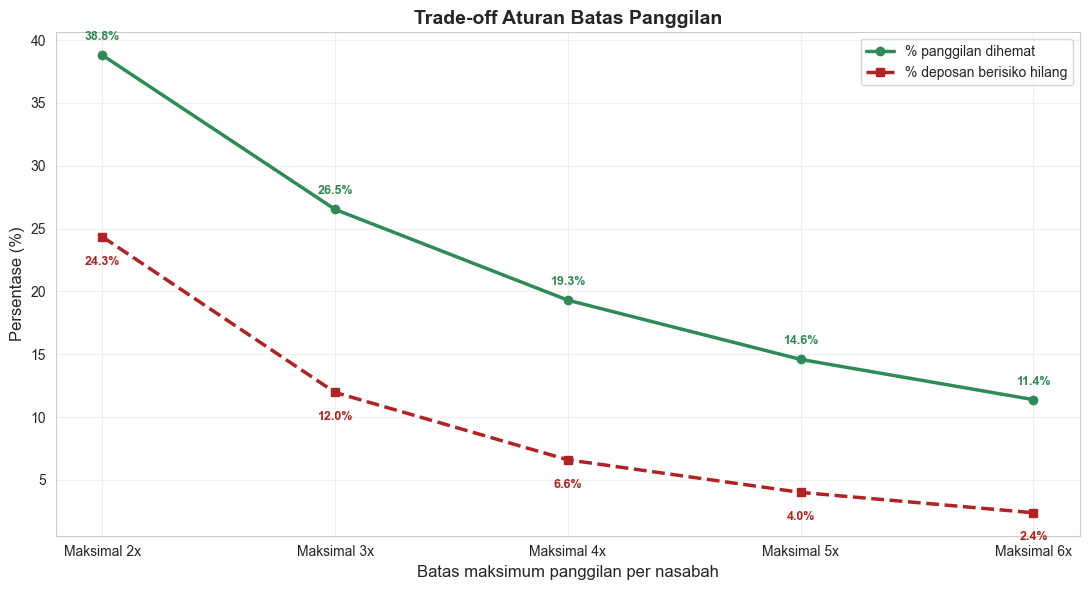

,Aturan,Panggilan dihemat,% panggilan dihemat,Deposan berisiko hilang,% deposan hilang,Rasio hemat : korban
0,Maksimal 2x,41017,38.79,1129,24.34,1.59
1,Maksimal 3x,28043,26.52,555,11.96,2.22
2,Maksimal 4x,20409,19.30,306,6.60,2.93
3,Maksimal 5x,15425,14.59,186,4.01,3.64
4,Maksimal 6x,12040,11.39,111,2.39,4.76


In [89]:
# Simulasi aturan berhenti: berapa panggilan dihemat vs berapa deposan berisiko hilang
hasil = []
for cap in [2, 3, 4, 5, 6]:
    hemat  = (df_clean['campaign'] - cap).clip(lower=0).sum()
    hilang = df_clean.loc[df_clean['campaign'] > cap, 'y'].sum()
    hasil.append([f'Maksimal {cap}x', hemat, round(hemat / total_call * 100, 2),
                  hilang, round(hilang / n_deposan * 100, 2),
                  round((hemat / total_call * 100) / (hilang / n_deposan * 100), 2)])
cap_df = pd.DataFrame(hasil, columns=['Aturan', 'Panggilan dihemat', '% panggilan dihemat',
                                      'Deposan berisiko hilang', '% deposan hilang',
                                      'Rasio hemat : korban'])

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(cap_df['Aturan'], cap_df['% panggilan dihemat'], 'o-', lw=2.5,
        color='seagreen', label='% panggilan dihemat')
ax.plot(cap_df['Aturan'], cap_df['% deposan hilang'], 's--', lw=2.5,
        color='firebrick', label='% deposan berisiko hilang')
for i, r in cap_df.iterrows():
    ax.text(i, r['% panggilan dihemat'] + 1.2, f"{r['% panggilan dihemat']:.1f}%",
            ha='center', fontsize=9, color='seagreen', weight='bold')
    ax.text(i, r['% deposan hilang'] - 2.2, f"{r['% deposan hilang']:.1f}%",
            ha='center', fontsize=9, color='firebrick', weight='bold')
ax.set_xlabel("Batas maksimum panggilan per nasabah", fontsize=12)
ax.set_ylabel("Persentase (%)", fontsize=12)
ax.set_title("Trade-off Aturan Batas Panggilan", fontsize=14, weight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(cap_df)

**INSIGHT AKHIR**

Telepon seluler berkonversi **14,74%**, sedangkan telepon rumah hanya **5,23%**. Selisih **+9,51 poin persentase** ini signifikan sangat kuat (z = 29,38; p < 0,001), jadi bukan kebetulan sampel. Meskipun begitu, **36,53% panggilan masih diarahkan ke telepon rumah**, kanal yang terbukti paling lemah.

Untuk jumlah panggilan, conversion rate turun konsisten seiring bertambahnya kontak: panggilan ke-1 **13,04%**, ke-3 **10,75%**, ke-5 **7,50%**, hingga ke-11 ke atas hanya **3,11%**. Uji Mann-Whitney satu arah menegaskan deposan memang dihubungi lebih sedikit dibanding yang menolak (p = 1,8 x 10^-38). Artinya panggilan berulang tidak membujuk nasabah; nasabah yang berminat cenderung setuju lebih awal. Temuan ini menolak asumsi umum telemarketing bahwa semakin sering ditelepon semakin besar peluang closing.

Dari simulasi aturan berhenti, membatasi maksimal **4 panggilan per nasabah** menghemat **20.409 panggilan (19,30% beban kerja)** dengan risiko kehilangan **306 deposan (6,60%)**, atau rasio hemat banding korban **2,93 : 1**. Batas 2x memang menghemat 38,79% tetapi mengorbankan 24,34% deposan (rasio hanya 1,59 : 1), sehingga terlalu agresif.

**Rekomendasi**

1. Tetapkan batas keras 4 panggilan per nasabah per kampanye di sistem dialer, dan alihkan sisa kapasitas ke nasabah baru yang belum tersentuh.
2. Prioritaskan nomor seluler. Nasabah yang hanya memiliki telepon rumah ditempatkan pada prioritas terakhir, sambil menjalankan program pemutakhiran nomor ponsel nasabah.

**Estimasi dampak**

Batas 4 panggilan membebaskan 20.409 panggilan, setara menjangkau sekitar 7.900 nasabah baru pada rata-rata 2,57 panggilan per nasabah.

> Catatan: simulasi ini bersifat batas atas pada sisi korban. Data hanya mencatat total kontak per nasabah beserta hasil akhirnya, sehingga tidak dapat dipastikan bahwa deposan yang dihubungi 5x tidak akan tetap setuju pada panggilan ke-4. Angka 6,60% karena itu adalah risiko maksimum, bukan kerugian pasti.

### g. Bagaimana riwayat kampanye sebelumnya memengaruhi konversi?

Menurut hasil uji asosiasi di bagian b, `poutcome` adalah fitur dengan Cramer's V tertinggi (0,320). Pertanyaan yang akan kita jawab dalam analisa ini adalah: bagaimana hasil kampanye sebelumnya membedakan konversi nasabah pada kampanye sekarang?

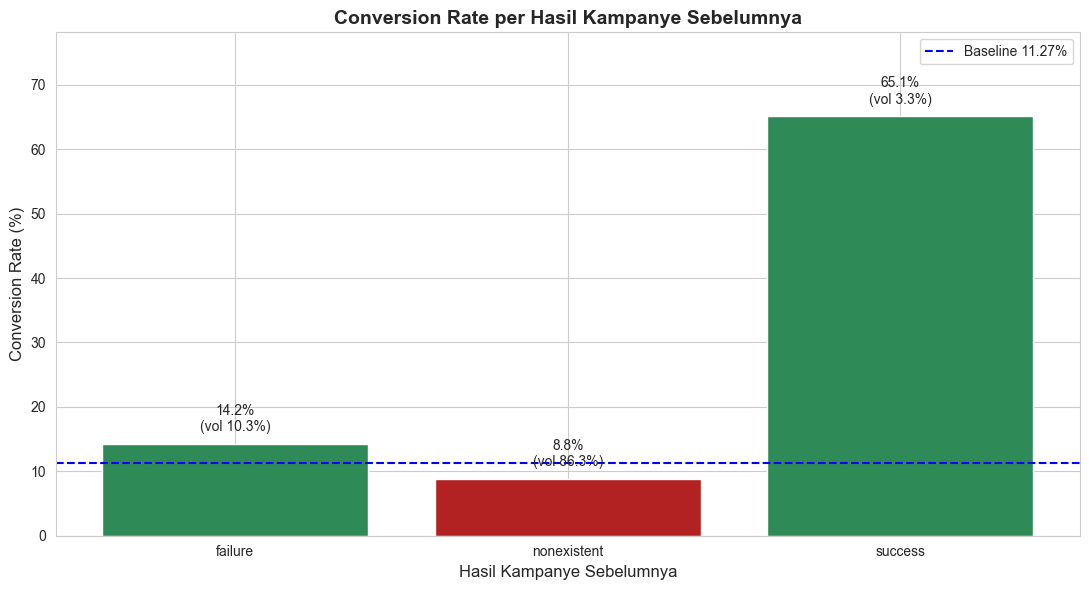

,count,sum,conv_rate,pct_volume,pct_deposan,lift
poutcome,,,,,,
failure,4252,605,14.23,10.33,13.04,1.26
nonexistent,35551,3140,8.83,86.34,67.69,0.78
success,1373,894,65.11,3.33,19.27,5.78


In [90]:
# Tabel ringkas hasil kampanye sebelumnya
pout_conv = df_clean.groupby('poutcome', observed=True)['y'].agg(['count', 'sum', 'mean'])
pout_conv.columns = ['count', 'sum', 'conv_rate']
pout_conv['conv_rate'] = (pout_conv['conv_rate'] * 100).round(2)
pout_conv['pct_volume'] = (pout_conv['count'] / n_nasabah * 100).round(2)
pout_conv['pct_deposan'] = (pout_conv['sum'] / n_deposan * 100).round(2)
pout_conv['lift'] = (pout_conv['conv_rate'] / baseline_rate).round(2)

fig, ax = plt.subplots(figsize=(11, 6))
t = pout_conv
ax.bar(t.index.astype(str), t['conv_rate'],
       color=np.where(t['conv_rate'] > baseline_rate, 'seagreen', 'firebrick'))
for i, (cr, pv) in enumerate(zip(t['conv_rate'], t['pct_volume'])):
    ax.text(i, cr + t['conv_rate'].max()*0.03, f'{cr:.1f}%\n(vol {pv:.1f}%)', ha='center', fontsize=10)
ax.axhline(baseline_rate, color='blue', linestyle='--', label=f'Baseline {baseline_rate:.2f}%')
ax.set_ylim(0, max(t['conv_rate'].max(), baseline_rate) * 1.2)
ax.set_xlabel("Hasil Kampanye Sebelumnya", fontsize=12)
ax.set_ylabel("Conversion Rate (%)", fontsize=12)
ax.set_title("Conversion Rate per Hasil Kampanye Sebelumnya", fontsize=14, weight="bold")
ax.legend()
plt.tight_layout()
plt.show()

display(pout_conv)

Sekarang kita masuk ke bagian inferensial. Sama seperti bagian c, d, dan f, yang dibandingkan adalah proporsi deposan pada dua kelompok yang saling bebas, sehingga ujinya two-proportion z-test.

Berikut adalah hipotesis uji:
- H0: Conversion rate `poutcome = success` = `poutcome = nonexistent`
- H1: Conversion rate `poutcome = success` != `poutcome = nonexistent`

H0 ditolak bila p-value < 0.05

In [91]:
# Inferensial Analysis
g1 = df_clean.loc[df_clean['poutcome'] == 'success', 'y']
g2 = df_clean.loc[df_clean['poutcome'] == 'nonexistent', 'y']
n1, n2 = len(g1), len(g2)
p1, p2 = g1.mean(), g2.mean()
p_gab  = (g1.sum() + g2.sum()) / (n1 + n2)
z      = (p1 - p2) / np.sqrt(p_gab * (1 - p_gab) * (1/n1 + 1/n2))
p_val  = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"poutcome = 'success' ({p1*100:.2f}%, n={n1:,}) vs 'nonexistent' ({p2*100:.2f}%, n={n2:,})")
print(f"  selisih = {(p1-p2)*100:+.2f} poin persentase | z = {z:.2f} | p-value = {p_val:.3e}"
      f" | {'SIGNIFIKAN' if p_val < 0.05 else 'tidak signifikan'} pada alpha 5%")

poutcome = 'success' (65.11%, n=1,373) vs 'nonexistent' (8.83%, n=35,551)
  selisih = +56.28 poin persentase | z = 65.60 | p-value = 0.000e+00 | SIGNIFIKAN pada alpha 5%


**INSIGHT AKHIR**

Nasabah yang pernah menerima tawaran pada kampanye sebelumnya berkonversi **65,11%**, atau **lift 5,78x** dan **+56,28 poin persentase** di atas nasabah yang belum pernah dikontak (8,83%). Selisih ini signifikan sangat kuat (z = 65,60; p < 0,001) dan menjadikan `poutcome` prediktor terkuat yang benar-benar tersedia sebelum panggilan dilakukan.

Yang menarik, nasabah yang **pernah menolak** (`failure`) tetap berkonversi **14,23%**, masih di atas baseline dan lebih tinggi daripada nasabah yang belum pernah disentuh sama sekali. Jadi penolakan pada kampanye lalu bukan alasan untuk mencoret nasabah; justru pernah berinteraksi dengan bank saja sudah menjadi sinyal positif.

**Rekomendasi**

Jadikan basis data kampanye lama sebagai sumber call list lapis pertama, dengan urutan prioritas `success` lalu `failure` lalu `nonexistent`. Nasabah dengan `poutcome = success` layak ditangani agen senior karena peluang closing-nya di atas 65%.

**Estimasi dampak**

Menghubungi seluruh 1.373 nasabah `success` lebih dulu menghasilkan sekitar **894 deposan hanya dari 3,33% volume panggilan**, setara **19,27% dari total deposan** dengan hanya 3,33% beban kerja kampanye penuh.

> Catatan: segmen `success` hanya mencakup 3,33% populasi, sehingga tidak bisa menjadi tumpuan utama volume kampanye. Nilainya terletak pada kepastian konversinya yang sangat tinggi, bukan pada skalanya.

### h. Validasi asumsi pemodelan: apakah `duration` merupakan kebocoran data?

Sebelum masuk ke tahap sintesis, ada satu kolom yang perlu divalidasi lebih dulu, yaitu `duration` atau durasi panggilan terakhir. Pertanyaan yang akan kita jawab dalam analisa ini adalah: seberapa tajam durasi panggilan memisahkan deposan dari non-deposan, dan apakah kolom ini layak dipakai sebagai fitur model?

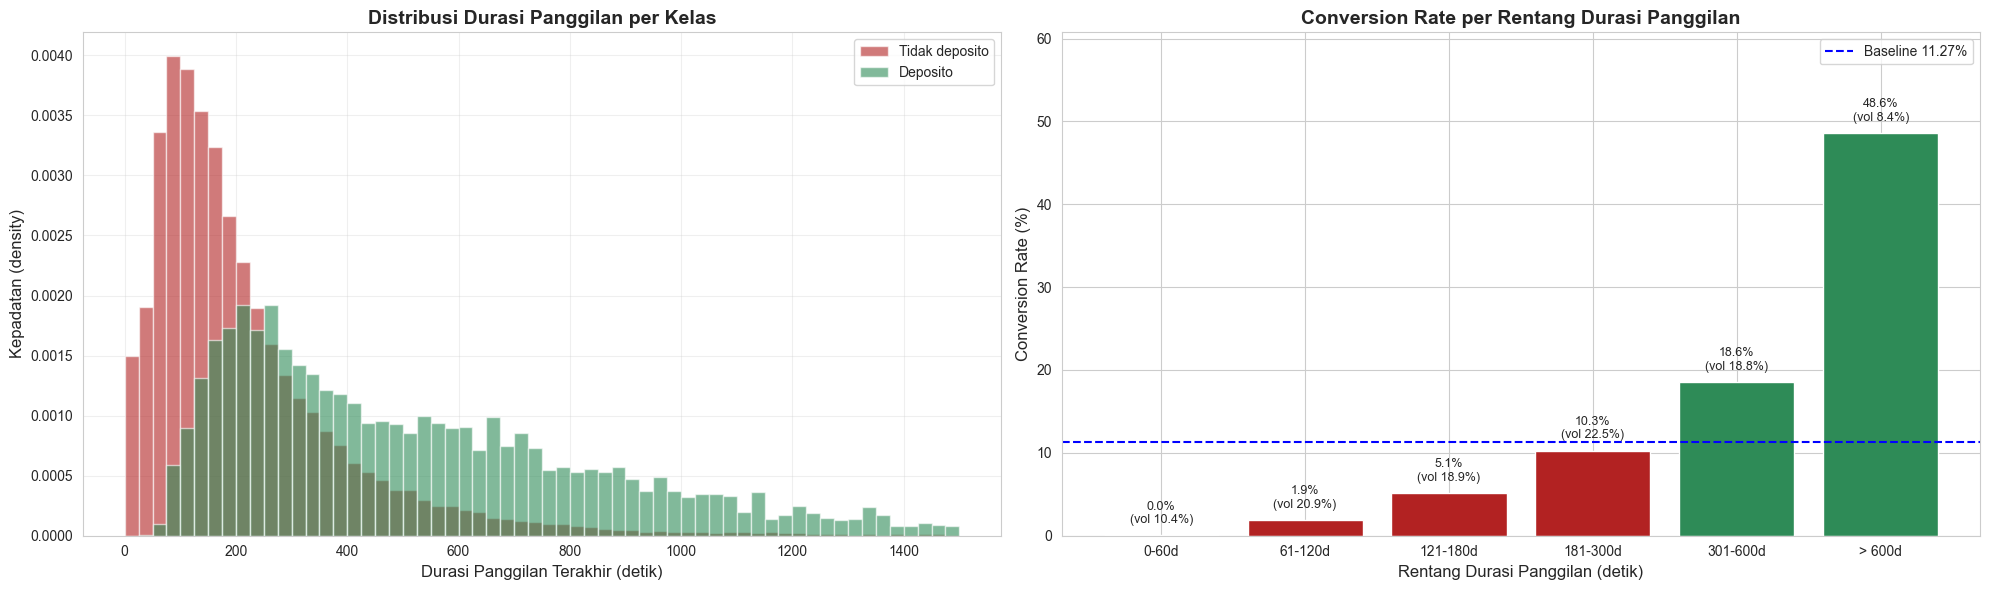

,count,sum,conv_rate,pct_volume,lift
rentang_durasi,,,,,
0-60d,4284,1,0.02,10.40,0.00
61-120d,8628,165,1.91,20.95,0.17
121-180d,7784,398,5.11,18.90,0.45
181-300d,9278,953,10.27,22.53,0.91
301-600d,7738,1438,18.58,18.79,1.65
> 600d,3464,1684,48.61,8.41,4.31


Panggilan berdurasi 0 detik : 4 baris, deposan: 0
Korelasi duration vs y      : 0.4053


In [92]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

## Distribusi durasi panggilan per kelas
for kelas, warna, nama in [(0, 'firebrick', 'Tidak deposito'), (1, 'seagreen', 'Deposito')]:
    axes[0].hist(df_clean.loc[df_clean['y'] == kelas, 'duration'], bins=60, range=(0, 1500),
                 alpha=0.6, color=warna, label=nama, density=True)
axes[0].set_xlabel("Durasi Panggilan Terakhir (detik)", fontsize=12)
axes[0].set_ylabel("Kepadatan (density)", fontsize=12)
axes[0].set_title("Distribusi Durasi Panggilan per Kelas", fontsize=14, weight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

## Conversion rate per rentang durasi
df_clean['rentang_durasi'] = pd.cut(df_clean['duration'],
                                    bins=[-1, 60, 120, 180, 300, 600, 5000],
                                    labels=['0-60d', '61-120d', '121-180d', '181-300d', '301-600d', '> 600d'])
dur_conv = df_clean.groupby('rentang_durasi', observed=True)['y'].agg(['count', 'sum', 'mean'])
dur_conv.columns = ['count', 'sum', 'conv_rate']
dur_conv['conv_rate'] = (dur_conv['conv_rate'] * 100).round(2)
dur_conv['pct_volume'] = (dur_conv['count'] / n_nasabah * 100).round(2)
dur_conv['lift'] = (dur_conv['conv_rate'] / baseline_rate).round(2)

t = dur_conv
axes[1].bar(t.index.astype(str), t['conv_rate'],
            color=np.where(t['conv_rate'] > baseline_rate, 'seagreen', 'firebrick'))
for i, (cr, pv) in enumerate(zip(t['conv_rate'], t['pct_volume'])):
    axes[1].text(i, cr + t['conv_rate'].max()*0.03, f'{cr:.1f}%\n(vol {pv:.1f}%)', ha='center', fontsize=9)
axes[1].axhline(baseline_rate, color='blue', linestyle='--', label=f'Baseline {baseline_rate:.2f}%')
axes[1].set_ylim(0, t['conv_rate'].max() * 1.25)
axes[1].set_xlabel("Rentang Durasi Panggilan (detik)", fontsize=12)
axes[1].set_ylabel("Conversion Rate (%)", fontsize=12)
axes[1].set_title("Conversion Rate per Rentang Durasi Panggilan", fontsize=14, weight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

display(dur_conv)
print(f"Panggilan berdurasi 0 detik : {(df_clean['duration'] == 0).sum()} baris, "
      f"deposan: {df_clean.loc[df_clean['duration'] == 0, 'y'].sum()}")
print(f"Korelasi duration vs y      : {df_clean['duration'].corr(df_clean['y']):.4f}")

**INSIGHT AKHIR**

Panggilan berdurasi **0-60 detik hanya menghasilkan 1 deposan dari 4.284 kontak (0,02%)**, sedangkan panggilan **di atas 600 detik berkonversi 48,61%**. Rentangnya mencapai sekitar 2.400x lipat, jauh melampaui efek fitur mana pun yang sudah kita periksa. Korelasinya terhadap target juga **0,4053**, tertinggi di antara seluruh fitur numerik.

Namun justru ketajaman inilah masalahnya. **Durasi panggilan baru diketahui setelah panggilan selesai**, sedangkan model harus memutuskan siapa yang ditelepon **sebelum** panggilan terjadi. Hubungannya pun terbalik secara kausal: nasabah tidak berdeposito karena teleponnya lama, melainkan teleponnya menjadi lama karena nasabah tertarik. Bahkan terdapat 4 baris berdurasi 0 detik dengan target selalu `no`, yang menegaskan bahwa `duration` sesungguhnya merekam hasil, bukan penyebab.

**Keputusan**

`duration` **dikeluarkan dari seluruh fitur model**. Kolom ini tetap dipertahankan untuk keperluan analisis operasional, misalnya menetapkan tolok ukur durasi percakapan bagi agen, tetapi tidak pernah masuk sebagai input prediksi. Bila diabaikan, model akan menghasilkan metrik uji yang tampak sangat baik namun tidak dapat dipakai sama sekali di produksi, karena nilainya belum ada pada saat call list disusun.

### i. Analisis multivariat: menggabungkan tiga dimensi sekaligus

Seluruh analisis di atas masih memeriksa satu dimensi pada satu waktu. Sesuai kerangka Data - Information - Knowledge - Insight - Wisdom, insight terkuat baru muncul ketika tiga variabel atau lebih dihubungkan sekaligus. Pertanyaan yang akan kita jawab dalam analisa ini adalah: seberapa tajam kombinasi kanal kontak, riwayat kampanye, dan segmen usia memisahkan konversi?

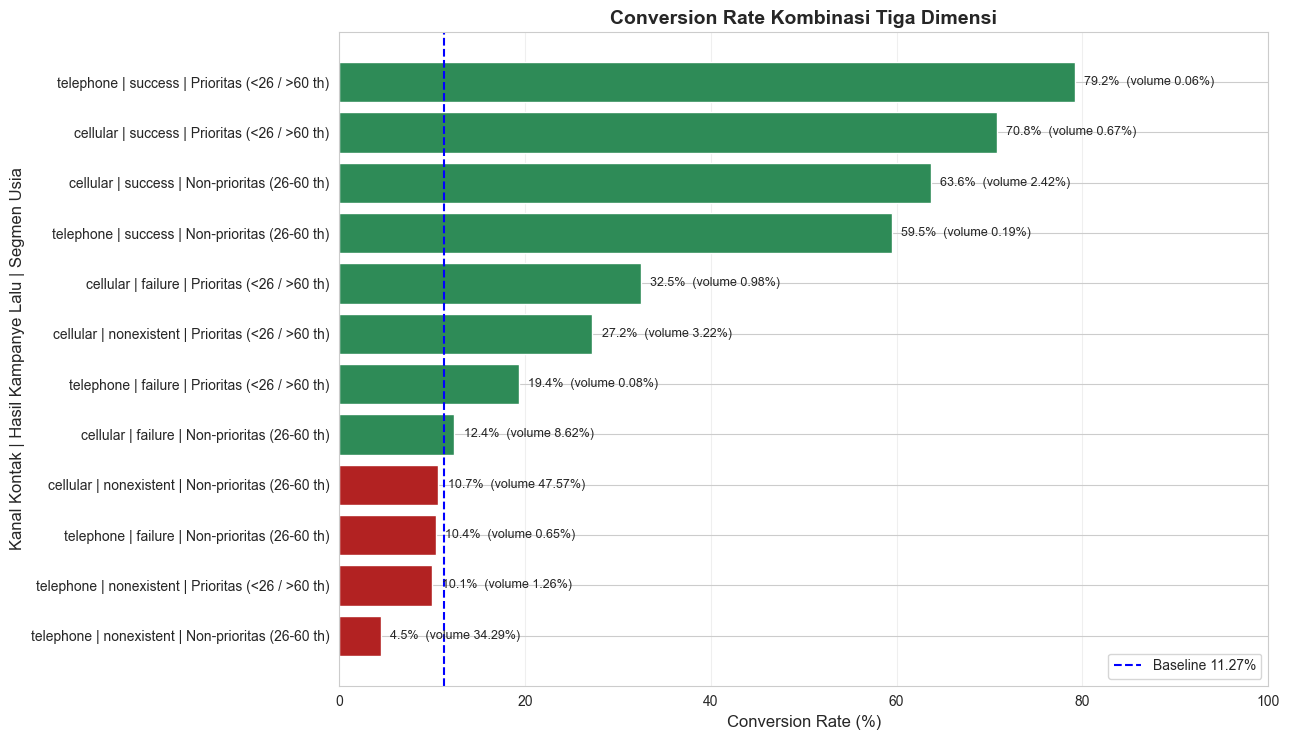

count   sum  conv_rate  \
contact   poutcome    segmen_usia                                        
telephone success     Prioritas (<26 / >60 th)     24    19      79.17   
cellular  success     Prioritas (<26 / >60 th)    274   194      70.80   
                      Non-prioritas (26-60 th)    996   634      63.65   
telephone success     Non-prioritas (26-60 th)     79    47      59.49   
cellular  failure     Prioritas (<26 / >60 th)    403   131      32.51   
          nonexistent Prioritas (<26 / >60 th)   1325   361      27.25   
telephone failure     Prioritas (<26 / >60 th)     31     6      19.35   
cellular  failure     Non-prioritas (26-60 th)   3549   440      12.40   
          nonexistent Non-prioritas (26-60 th)  19588  2092      10.68   
telephone failure     Non-prioritas (26-60 th)    269    28      10.41   
          nonexistent Prioritas (<26 / >60 th)    517    52      10.06   
                      Non-prioritas (26-60 th)  14121   635       4.50   

                                                pct_volume  pct_deposan  lift  
contact   poutcome    segmen_usia                                              
telephone success     Prioritas (<26 / >60 th)        0.06         0.41  7.03  
cellular  success     Prioritas (<26 / >60 th)        0.67         4.18  6.28  
                      Non-prioritas (26-60 th)        2.42        13.67  5.65  
telephone success     Non-prioritas (26-60 th)        0.19         1.01  5.28  
cellular  failure     Prioritas (<26 / >60 th)        0.98         2.82  2.89  
          nonexistent Prioritas (<26 / >60 th)        3.22         7.78  2.42  
telephone failure     Prioritas (<26 / >60 th)        0.08         0.13  1.72  
cellular  failure     Non-prioritas (26-60 th)        8.62         9.48  1.10  
          nonexistent Non-prioritas (26-60 th)       47.57        45.10  0.95  
telephone failure     Non-prioritas (26-60 th)        0.65         0.60  0.92  
          nonexistent Prioritas (<26 / >60 th)        1.26         1.12  0.89  
                      Non-prioritas (26-60 th)       34.29        13.69  0.40

In [93]:
# Segmen usia prioritas berdasarkan pola U di bagian c
df_clean['segmen_usia'] = np.where((df_clean['age'] > 60) | (df_clean['age'] < 26),
                                   'Prioritas (<26 / >60 th)', 'Non-prioritas (26-60 th)')

multi = df_clean.groupby(['contact', 'poutcome', 'segmen_usia'], observed=True)['y'].agg(['count', 'sum', 'mean'])
multi.columns = ['count', 'sum', 'conv_rate']
multi['conv_rate'] = (multi['conv_rate'] * 100).round(2)
multi['pct_volume'] = (multi['count'] / n_nasabah * 100).round(2)
multi['pct_deposan'] = (multi['sum'] / n_deposan * 100).round(2)
multi['lift'] = (multi['conv_rate'] / baseline_rate).round(2)
multi = multi.sort_values('conv_rate', ascending=False)

fig, ax = plt.subplots(figsize=(13, 7.5))
label = [f"{a} | {b} | {c}" for a, b, c in multi.index]
ax.barh(label[::-1], multi['conv_rate'][::-1],
        color=np.where(multi['conv_rate'][::-1] > baseline_rate, 'seagreen', 'firebrick'))
for i, (cr, pv) in enumerate(zip(multi['conv_rate'][::-1], multi['pct_volume'][::-1])):
    ax.text(cr + 1, i, f'{cr:.1f}%  (volume {pv:.2f}%)', va='center', fontsize=9)
ax.axvline(baseline_rate, color='blue', linestyle='--', label=f'Baseline {baseline_rate:.2f}%')
ax.set_xlim(0, 100)
ax.set_xlabel("Conversion Rate (%)", fontsize=12)
ax.set_ylabel("Kanal Kontak | Hasil Kampanye Lalu | Segmen Usia", fontsize=12)
ax.set_title("Conversion Rate Kombinasi Tiga Dimensi", fontsize=14, weight="bold")
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

display(multi)

**INSIGHT AKHIR**

Menyilangkan kanal kontak, riwayat kampanye, dan segmen usia memisahkan populasi dari **4,50% hingga 79,17%**, rentang sekitar 17x lipat. Bandingkan dengan variabel terbaik secara tunggal, `poutcome`, yang hanya merentang 8,83% sampai 65,11%. Kombinasi jelas mengalahkan variabel tunggal.

Segmen terbaik adalah nasabah **berusia di atas 60 atau di bawah 26 tahun, pernah sukses di kampanye sebelumnya, dan dihubungi via seluler** dengan konversi **70,80%**, meski volumenya hanya 0,67%. Kombinasi telepon rumah pada kelompok yang sama bahkan mencapai 79,17%, tetapi hanya berbasis 24 nasabah sehingga tidak dapat digeneralisasi. Ini contoh mengapa lift tinggi harus selalu dibaca bersama volumenya.

Segmen terburuk adalah nasabah **berusia 26-60 tahun, belum pernah dikontak, via telepon rumah** dengan konversi **4,50%**. Masalahnya, segmen ini justru menyerap **34,29% seluruh panggilan**, artinya lebih dari sepertiga kapasitas telemarketing dihabiskan pada kombinasi terlemah yang ada.

**Insight utama**

Masalah kampanye ini **bukan kekurangan nasabah potensial, melainkan salah alokasi kapasitas**. Segmen berkualitas tinggi tersedia dan sudah teridentifikasi, tetapi hampir tidak tersentuh, sementara mayoritas panggilan mengalir ke kombinasi bernilai terendah.

**Rekomendasi**

Ganti aturan penargetan satu variabel dengan matriks prioritas multi-dimensi yang menggabungkan kanal, riwayat, dan usia. Operasionalisasinya disusun pada bagian j.

### j. Sintesis: skor prioritas dan cumulative gain

Seluruh temuan dari bagian b sampai i sekarang dirangkum menjadi satu skor prioritas sederhana berbasis aturan. Pertanyaan yang akan kita jawab dalam analisa ini adalah: berapa persen daftar nasabah yang sebenarnya perlu dihubungi, dan berapa besar penghematannya?

Bobot tiap aturan disusun proporsional terhadap kekuatan asosiasi (Cramer's V dari bagian b) dan besar selisih konversi yang sudah diuji signifikansinya:

| Aturan | Bobot | Dasar temuan |
|---|---|---|
| `poutcome` = `success` / `failure` | +3,0 / +1,0 | asosiasi terkuat, Cramer's V 0,320 (bagian b) |
| Bulan emas / April | +2,0 / +1,0 | Cramer's V 0,274 (bagian b), bulan emas dari bagian d |
| Usia di atas 60 atau di bawah 26 tahun | +1,5 | pola U yang kuat (bagian c) |
| Kanal seluler | +1,0 | Cramer's V 0,145 (bagian b) |
| Pekerjaan pelajar atau pensiunan | +1,0 | Cramer's V 0,152 (bagian b) |
| Status kredit `unknown` | -1,0 | selisih -7,73 pp, signifikan (bagian c) |

Skor ini berfungsi sebagai pembanding untuk model machine learning pada bab berikutnya: model baru layak diadopsi hanya jika mampu mengungguli aturan sederhana ini.

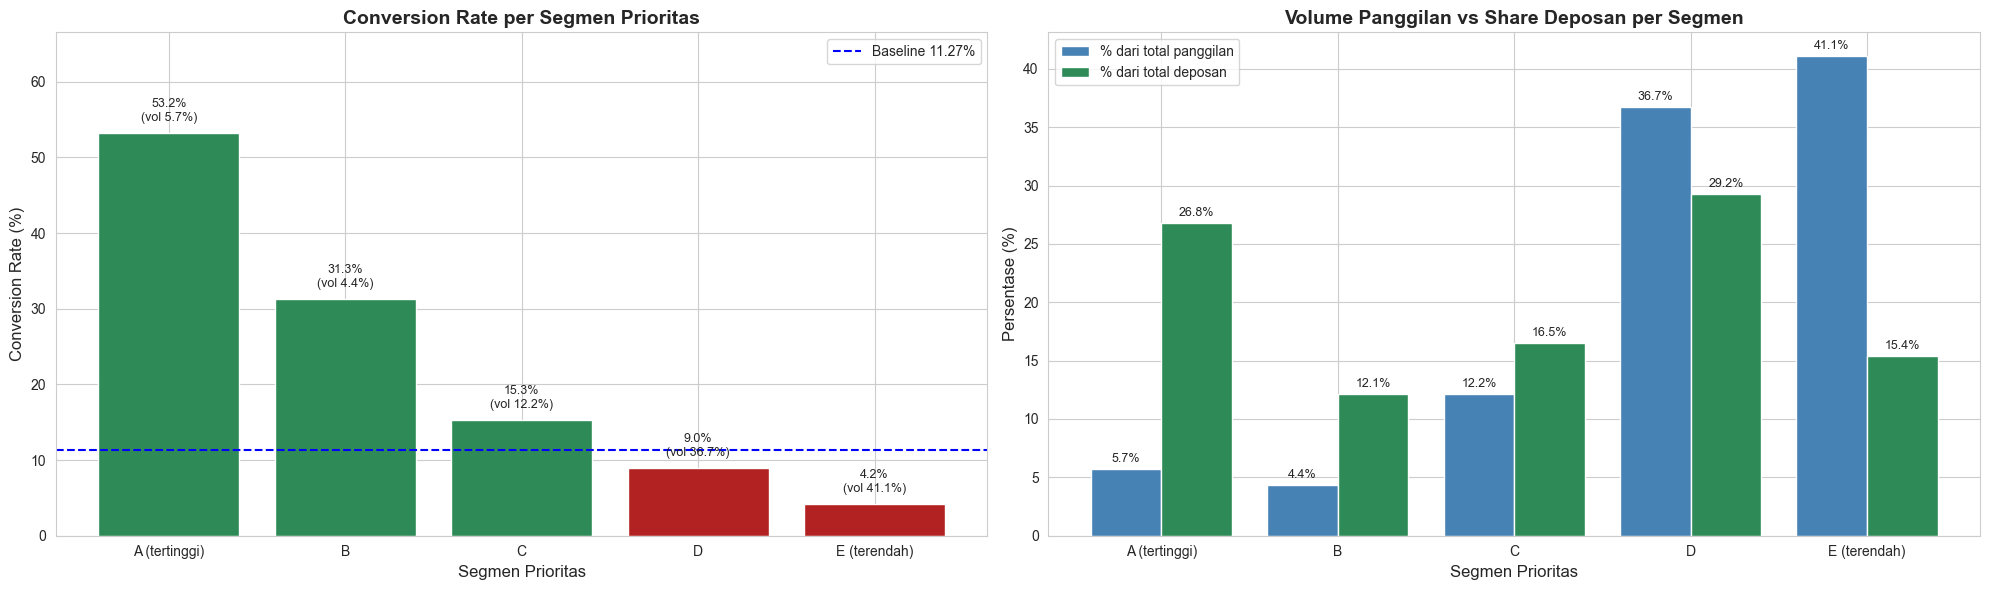

,count,sum,conv_rate,pct_volume,pct_deposan,lift
segmen_prioritas,,,,,,
A (tertinggi),2333,1242,53.24,5.67,26.77,4.73
B,1801,563,31.26,4.37,12.14,2.77
C,5002,764,15.27,12.15,16.47,1.36
D,15129,1357,8.97,36.74,29.25,0.80
E (terendah),16911,713,4.22,41.07,15.37,0.37


Dampak bila hanya sebagian daftar teratas yang dihubungi:

Segmen D ke atas  : 24,265 panggilan ( 58.9% volume) -> 3,926 deposan ( 84.6% deposan tertangkap | conv 16.18%)
Segmen C ke atas  :  9,136 panggilan ( 22.2% volume) -> 2,569 deposan ( 55.4% deposan tertangkap | conv 28.12%)
Segmen B ke atas  :  4,809 panggilan ( 11.7% volume) -> 1,905 deposan ( 41.1% deposan tertangkap | conv 39.61%)
Segmen A saja     :  2,827 panggilan (  6.9% volume) -> 1,411 deposan ( 30.4% deposan tertangkap | conv 49.91%)


In [94]:
# Penyusunan skor prioritas
skor = pd.Series(0.0, index=df_clean.index)

# Riwayat kampanye
skor += np.where(df_clean['poutcome'] == 'success', 3.0,
                 np.where(df_clean['poutcome'] == 'failure', 1.0, 0.0))
# Musim (bulan emas)
skor += np.where(df_clean['month'].isin(['mar', 'sep', 'oct', 'dec']), 2.0,
                 np.where(df_clean['month'] == 'apr', 1.0, 0.0))
# Segmen usia
skor += np.where((df_clean['age'] > 60) | (df_clean['age'] < 26), 1.5, 0.0)
# Kanal kontak
skor += np.where(df_clean['contact'] == 'cellular', 1.0, 0.0)
# Pekerjaan produktif
skor += np.where(df_clean['job'].isin(['student', 'retired']), 1.0, 0.0)
# Penalti: status kredit tidak diketahui
skor += np.where(df_clean['default'] == 'unknown', -1.0, 0.0)

df_clean['skor_prioritas'] = skor
df_clean['segmen_prioritas'] = pd.cut(df_clean['skor_prioritas'],
                                      bins=[-2, 0.5, 1.5, 2.5, 3.5, 12],
                                      labels=['E (terendah)', 'D', 'C', 'B', 'A (tertinggi)'])

seg = df_clean.groupby('segmen_prioritas', observed=True)['y'].agg(['count', 'sum', 'mean'])
seg.columns = ['count', 'sum', 'conv_rate']
seg['conv_rate'] = (seg['conv_rate'] * 100).round(2)
seg['pct_volume'] = (seg['count'] / n_nasabah * 100).round(2)
seg['pct_deposan'] = (seg['sum'] / n_deposan * 100).round(2)
seg['lift'] = (seg['conv_rate'] / baseline_rate).round(2)
seg = seg.sort_values('conv_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

## Conversion Rate per Segmen Prioritas
t = seg
axes[0].bar(t.index.astype(str), t['conv_rate'],
            color=np.where(t['conv_rate'] > baseline_rate, 'seagreen', 'firebrick'))
for i, (cr, pv) in enumerate(zip(t['conv_rate'], t['pct_volume'])):
    axes[0].text(i, cr + t['conv_rate'].max()*0.03, f'{cr:.1f}%\n(vol {pv:.1f}%)', ha='center', fontsize=9)
axes[0].axhline(baseline_rate, color='blue', linestyle='--', label=f'Baseline {baseline_rate:.2f}%')
axes[0].set_ylim(0, t['conv_rate'].max() * 1.25)
axes[0].set_xlabel("Segmen Prioritas", fontsize=12)
axes[0].set_ylabel("Conversion Rate (%)", fontsize=12)
axes[0].set_title("Conversion Rate per Segmen Prioritas", fontsize=14, weight="bold")
axes[0].legend()

## Volume vs Share Deposan per Segmen
x = np.arange(len(seg))
lebar = 0.4
axes[1].bar(x - lebar/2, seg['pct_volume'], width=lebar, label='% dari total panggilan', color='steelblue')
axes[1].bar(x + lebar/2, seg['pct_deposan'], width=lebar, label='% dari total deposan', color='seagreen')
for i, (vol, share) in enumerate(zip(seg['pct_volume'], seg['pct_deposan'])):
    axes[1].text(i - lebar/2, vol + 0.6, f'{vol:.1f}%', ha='center', fontsize=9)
    axes[1].text(i + lebar/2, share + 0.6, f'{share:.1f}%', ha='center', fontsize=9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(seg.index)
axes[1].set_xlabel("Segmen Prioritas", fontsize=12)
axes[1].set_ylabel("Persentase (%)", fontsize=12)
axes[1].set_title("Volume Panggilan vs Share Deposan per Segmen", fontsize=14, weight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

display(seg)

# Dampak bila penargetan benar-benar diterapkan
print('Dampak bila hanya sebagian daftar teratas yang dihubungi:\n')
for ambang, label in [(1.0, 'Segmen D ke atas'), (2.0, 'Segmen C ke atas'),
                      (2.5, 'Segmen B ke atas'), (3.5, 'Segmen A saja')]:
    m = df_clean['skor_prioritas'] >= ambang
    print(f"{label:18s}: {m.sum():6,} panggilan ({m.sum()/n_nasabah*100:5.1f}% volume) -> "
          f"{df_clean.loc[m, 'y'].sum():5,} deposan "
          f"({df_clean.loc[m, 'y'].sum()/n_deposan*100:5.1f}% deposan tertangkap | "
          f"conv {df_clean.loc[m, 'y'].mean()*100:5.2f}%)")

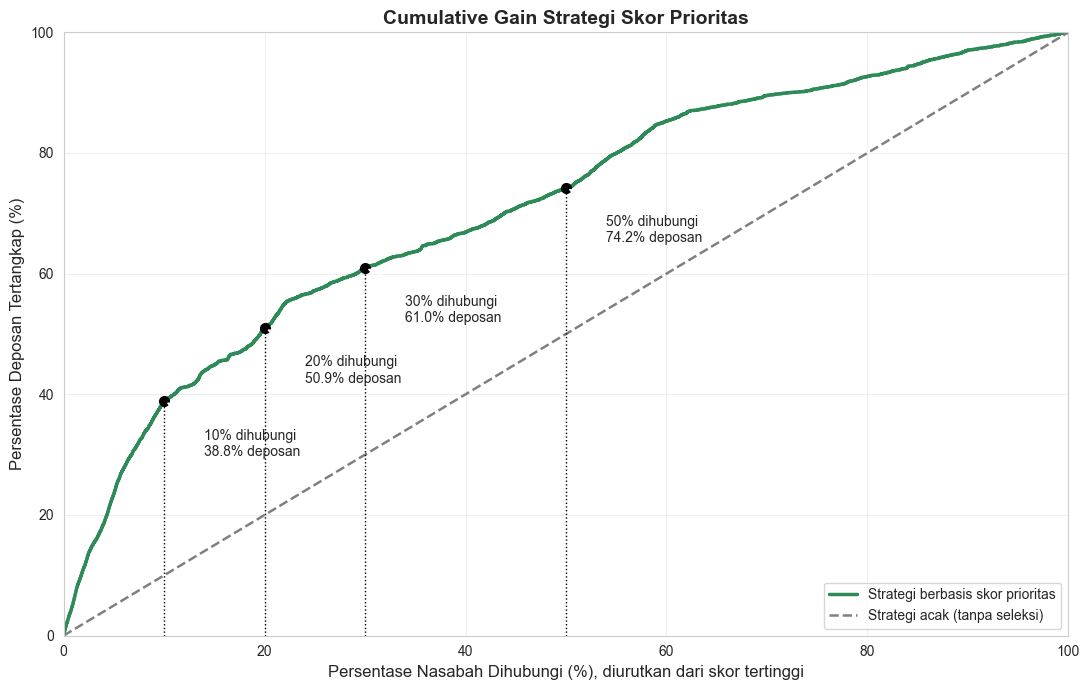

,% nasabah dihubungi,Jumlah nasabah,Deposan ditangkap,% deposan ditangkap,Lift
0,10%,4117,1801,38.82,3.88
1,20%,8235,2363,50.94,2.55
2,30%,12352,2830,61.00,2.03
3,40%,16470,3102,66.87,1.67
4,50%,20588,3443,74.22,1.48
5,60%,24705,3957,85.30,1.42
6,70%,28823,4153,89.52,1.28
7,80%,32940,4299,92.67,1.16
8,90%,37058,4502,97.05,1.08
9,100%,41176,4639,100.00,1.00


In [95]:
# Cumulative gain: berapa persen nasabah yang perlu dihubungi?
urut = df_clean.sort_values('skor_prioritas', ascending=False).reset_index(drop=True)
urut['kumulatif_deposan'] = urut['y'].cumsum()

persen_kontak  = (np.arange(1, len(urut) + 1) / len(urut)) * 100
persen_deposan = (urut['kumulatif_deposan'] / n_deposan) * 100

fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(persen_kontak, persen_deposan, lw=2.5, color='seagreen', label='Strategi berbasis skor prioritas')
ax.plot([0, 100], [0, 100], '--', lw=1.8, color='grey', label='Strategi acak (tanpa seleksi)')
for p in [10, 20, 30, 50]:
    k = int(len(urut) * p / 100) - 1
    capai = urut.loc[k, 'kumulatif_deposan'] / n_deposan * 100
    ax.plot([p, p], [0, capai], ':', color='black', lw=1)
    ax.plot(p, capai, 'o', color='black', ms=7)
    ax.annotate(f'{p}% dihubungi\n{capai:.1f}% deposan', xy=(p, capai),
                xytext=(p + 4, capai - 9), fontsize=10,
                arrowprops=dict(arrowstyle='->', lw=1))
ax.set_xlabel("Persentase Nasabah Dihubungi (%), diurutkan dari skor tertinggi", fontsize=12)
ax.set_ylabel("Persentase Deposan Tertangkap (%)", fontsize=12)
ax.set_title("Cumulative Gain Strategi Skor Prioritas", fontsize=14, weight="bold")
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

tabel_gain = []
for p in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
    k = int(len(urut) * p / 100) - 1
    dep = urut.loc[k, 'kumulatif_deposan']
    tabel_gain.append([f'{p}%', k + 1, dep, round(dep / n_deposan * 100, 2),
                       round((dep / (k + 1)) / (n_deposan / n_nasabah), 2)])
display(pd.DataFrame(tabel_gain, columns=['% nasabah dihubungi', 'Jumlah nasabah',
                                          'Deposan ditangkap', '% deposan ditangkap', 'Lift']))

**INSIGHT AKHIR**

Skor prioritas berbasis aturan memisahkan populasi dengan sangat tajam. **Segmen A berkonversi 53,24%** (lift 4,73x) meski hanya menyerap **5,67% volume**, sedangkan **segmen E berkonversi 4,22%** dengan **41,07% volume**. Dengan kata lain, empat dari sepuluh panggilan saat ini diarahkan ke kelompok dengan peluang terendah.

**Berapa persen nasabah yang perlu dihubungi?** Kurva cumulative gain menunjukkan menghubungi **30% nasabah berskor tertinggi sudah menangkap 61,00% deposan** (lift 2,03x), dan **50% teratas menangkap 74,22%**. Artinya separuh kapasitas telemarketing dapat dihentikan sambil tetap mempertahankan tiga perempat hasil.

**Berapa besar penghematannya?** Menghubungi hanya **segmen C ke atas** berarti **9.136 panggilan**, atau **77,8% lebih sedikit** dari sekarang, namun tetap menangkap **2.569 deposan (55,4% dari seluruh deposan)** dengan conversion rate naik dari **11,27% menjadi 28,12%**, sekitar 2,5x lipat. Bila target bank adalah pertumbuhan volume dana pihak ketiga dan bukan efisiensi biaya, **segmen D ke atas** lebih tepat karena tetap menangkap **84,6% deposan** dengan **41% lebih sedikit panggilan**.

**Trade-off yang harus disampaikan jujur ke stakeholder**

Skenario paling selektif mengorbankan **44,6% deposan** yang tersebar di segmen bawah. Pilihan itu rasional bila tujuannya efisiensi kapasitas, tetapi mengabaikan lifetime value nasabah. Karena itu keputusan seberapa selektif penargetan diterapkan harus dikembalikan ke target bisnis bank, bukan ditetapkan sepihak oleh analis.

> Catatan keterbatasan: skor ini bersifat aturan manual dengan bobot yang ditetapkan analis, dan dievaluasi pada data yang sama tanpa train-test split. Angkanya karena itu optimistis dan tidak dapat diklaim sebagai performa out-of-sample. Fungsinya adalah menjadi baseline yang harus dilampaui model machine learning pada bab berikutnya: model yang tidak mampu mengungguli lift 2,03x pada 30% populasi teratas tidak layak diadopsi.

### k. Ringkasan insight dan rekomendasi actionable

Bagian terakhir ini merangkum seluruh temuan dari bagian a sampai j ke dalam satu tabel yang langsung menghubungkan setiap temuan kuantitatif dengan tindakan yang bisa diambil tim telemarketing beserta estimasi dampaknya.

In [96]:
ringkasan = pd.DataFrame([
    ['WHO  - Usia',       'Usia >60 berkonversi 45,5% vs kelompok 35-44 hanya 8,5%',
     'Kuota harian minimum untuk nasabah usia >60 & <26', '+36,9 pp per panggilan direalokasi'],
    ['WHO  - Pekerjaan',  'Pelajar 31,4% & pensiunan 25,3% vs blue-collar 6,9%',
     'Turunkan porsi blue-collar dari antrean panggilan', '+20,5 pp per panggilan direalokasi'],
    ['WHO  - Kredit',     "default 'unknown' 5,2% vs 'no' 12,9% (20,9% populasi)",
     'Prioritas terendah bila status kredit tak diketahui', '-7,7 pp dihindari'],
    ['WHEN - Bulan',      'Mar/Sep/Okt/Des 4x baseline; Mei serap 33,4% volume utk 19,1% deposan',
     'Realokasi kalender + uji A/B sebelum diterapkan penuh', '+1.102 deposan potensial'],
    ['WHY  - Makro',      'Euribor <1,5% -> konversi 24,0% vs 4,8% saat suku bunga tinggi',
     'Jadikan level Euribor pemicu intensitas kampanye', 'Efek terkuat di seluruh data'],
    ['HOW  - Kanal',      'Seluler 14,7% vs telepon rumah 5,2%',
     'Prioritaskan nomor seluler; program update kontak', '+9,5 pp per panggilan'],
    ['HOW  - Intensitas', 'Konversi turun 13,0% -> 3,1% dari panggilan ke-1 ke ke-11+',
     'Batas keras 4 panggilan/nasabah di sistem dialer', 'Hemat 19,3% beban kerja'],
    ['WHAT - Riwayat',    "poutcome 'success' 65,1% (lift 5,8x); 'failure' 14,2% masih > baseline",
     'Call list lapis pertama dari basis kampanye lama', '894 deposan dari 3,3% volume'],
    ['MODEL - Leakage',   'duration berkorelasi 0,405 tapi baru diketahui setelah panggilan',
     'Keluarkan duration dari seluruh fitur model', 'Menghindari model tak terpakai'],
    ['TIDAK berpengaruh', 'housing (p=0,057) & loan (p=0,577) tidak signifikan',
     'Keluarkan dari kriteria segmentasi manual', 'Hindari segmentasi keliru'],
], columns=['Dimensi', 'Temuan (kuantitatif)', 'Rekomendasi (action)', 'Estimasi dampak'])

display(ringkasan.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}))

,Dimensi,Temuan (kuantitatif),Rekomendasi (action),Estimasi dampak
0,WHO - Usia,"Usia >60 berkonversi 45,5% vs kelompok 35-44 hanya 8,5%",Kuota harian minimum untuk nasabah usia >60 & <26,"+36,9 pp per panggilan direalokasi"
1,WHO - Pekerjaan,"Pelajar 31,4% & pensiunan 25,3% vs blue-collar 6,9%",Turunkan porsi blue-collar dari antrean panggilan,"+20,5 pp per panggilan direalokasi"
2,WHO - Kredit,"default 'unknown' 5,2% vs 'no' 12,9% (20,9% populasi)",Prioritas terendah bila status kredit tak diketahui,"-7,7 pp dihindari"
3,WHEN - Bulan,"Mar/Sep/Okt/Des 4x baseline; Mei serap 33,4% volume utk 19,1% deposan",Realokasi kalender + uji A/B sebelum diterapkan penuh,+1.102 deposan potensial
4,WHY - Makro,"Euribor <1,5% -> konversi 24,0% vs 4,8% saat suku bunga tinggi",Jadikan level Euribor pemicu intensitas kampanye,Efek terkuat di seluruh data
5,HOW - Kanal,"Seluler 14,7% vs telepon rumah 5,2%",Prioritaskan nomor seluler; program update kontak,"+9,5 pp per panggilan"
6,HOW - Intensitas,"Konversi turun 13,0% -> 3,1% dari panggilan ke-1 ke ke-11+",Batas keras 4 panggilan/nasabah di sistem dialer,"Hemat 19,3% beban kerja"
7,WHAT - Riwayat,"poutcome 'success' 65,1% (lift 5,8x); 'failure' 14,2% masih > baseline",Call list lapis pertama dari basis kampanye lama,"894 deposan dari 3,3% volume"
8,MODEL - Leakage,"duration berkorelasi 0,405 tapi baru diketahui setelah panggilan",Keluarkan duration dari seluruh fitur model,Menghindari model tak terpakai
9,TIDAK berpengaruh,"housing (p=0,057) & loan (p=0,577) tidak signifikan",Keluarkan dari kriteria segmentasi manual,Hindari segmentasi keliru


**KESIMPULAN SECTION E**

**Diagnosis utama.** Kampanye telemarketing ini tidak kekurangan nasabah potensial, melainkan salah mengalokasikan kapasitas. Segmen berkonversi tinggi tersedia, teridentifikasi, dan terbukti signifikan secara statistik, tetapi konsisten menerima porsi panggilan paling kecil. Pola yang sama berulang di setiap dimensi:

| Dimensi | Segmen terbaik | Konversi | Share volume yang diterima |
|---|---|---:|---:|
| Bulan | Mar/Sep/Okt/Des | 46,45% | 4,89% |
| Pekerjaan | Pelajar + pensiunan | 27,34% | 6,30% |
| Usia | Kelompok 65+ | 46,93% | 1,50% |
| Riwayat | `poutcome = success` | 65,11% | 3,33% |
| Kombinasi 3 dimensi | Seluler + success + usia prioritas | 70,80% | 0,67% |

**Jawaban atas problem statement:**

1. **Nasabah seperti apa?** Usia di atas 60 atau di bawah 26 tahun, berprofesi pensiunan atau pelajar, status kredit diketahui, dan pernah berinteraksi pada kampanye sebelumnya.
2. **Kapan?** Maret, September, Oktober, dan Desember, terutama pada periode suku bunga acuan rendah (Euribor di bawah 1,5%).
3. **Melalui kanal apa?** Telepon seluler, bukan telepon rumah.
4. **Berapa kali?** Maksimal 4 panggilan per nasabah per kampanye.
5. **Berapa persen daftar yang perlu dihubungi?** Cukup 30% teratas untuk menangkap 61% deposan, atau 50% teratas untuk 74%.
6. **Berapa penghematannya?** Menghubungi hanya segmen C ke atas memangkas 77,8% panggilan namun tetap menangkap 55,4% deposan, dan menaikkan conversion rate dari 11,27% menjadi 28,12%.

**Batasan analisis pada bagian ini**

- Seluruh temuan bersifat **berhubungan (asosiasif), bukan sebab-akibat (kausal)**. Data merupakan observasi kampanye historis tanpa randomisasi, sehingga efek bulan, kanal, dan segmen saling terjalin, terutama dengan kondisi makroekonomi.
- Kolom `month` tidak menyertakan tahun, sehingga pola musiman tidak dapat dipisahkan sepenuhnya dari tren suku bunga sepanjang periode data.
- Skor prioritas pada bagian j dievaluasi pada data yang sama tanpa validasi terpisah, sehingga angkanya optimistis dan berfungsi sebagai benchmark, bukan estimasi performa sesungguhnya.
- Analisis berhenti pada efisiensi panggilan dan jumlah deposan. Konversi ke nilai uang tidak dilakukan karena biaya per panggilan dan margin per deposito tidak tersedia pada data dan perlu divalidasi tim Finance lebih dulu.

**Jembatan ke tahap berikutnya.** Skor manual pada bagian j memakai 6 aturan dengan bobot yang ditetapkan analis. Machine learning dapat mempelajari bobot tersebut secara otomatis dari seluruh fitur sekaligus berikut interaksinya, serta menghasilkan probabilitas terkalibrasi yang ambangnya bisa disetel sesuai target bisnis. Tolok ukur yang harus dilampaui: **lift 2,03x pada 30% populasi teratas**.

## F. Methodology (Machine Learning)